In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import shap

import warnings
warnings.filterwarnings("ignore") #hides  unnecessary warning messages, making the output cleaner.

In [121]:
df = pd.read_csv(r"C:\Users\HOME\Desktop\loan\loan.csv")

In [122]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,0.0,2.258957e+06,...,10613.0,10613.000000,10613.0,10613.000000,8426.000000,10613.000000,10613.000000,33056.000000,33056.000000,33056.000000
mean,NaN,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309291e+01,4.458076e+02,7.799243e+04,NaN,1.882420e+01,...,3.0,155.006696,3.0,13.686422,454.840802,11628.036442,193.606331,5030.606922,47.775600,13.148596
std,NaN,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832114e+00,2.671737e+02,1.126962e+05,NaN,1.418333e+01,...,0.0,129.113137,0.0,9.728138,375.830737,7615.161123,198.694368,3692.027842,7.336379,8.192319
min,NaN,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,NaN,-1.000000e+00,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,NaN,1.189000e+01,...,3.0,59.370000,3.0,5.000000,174.967500,5628.730000,43.780000,2227.000000,45.000000,6.000000
50%,NaN,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,NaN,1.784000e+01,...,3.0,119.040000,3.0,15.000000,352.605000,10044.220000,132.890000,4172.855000,45.000000,14.000000
75%,NaN,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,NaN,2.449000e+01,...,3.0,213.260000,3.0,22.000000,622.792500,16114.940000,284.180000,6870.782500,50.000000,18.000000
max,NaN,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,NaN,9.990000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


In [124]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2260668
Number of columns: 145


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), str(36)
memory usage: 2.8 GB


In [126]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [127]:
df.describe() #mathematical summary of non categorical features

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,0.0,2.258957e+06,...,10613.0,10613.000000,10613.0,10613.000000,8426.000000,10613.000000,10613.000000,33056.000000,33056.000000,33056.000000
mean,NaN,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309291e+01,4.458076e+02,7.799243e+04,NaN,1.882420e+01,...,3.0,155.006696,3.0,13.686422,454.840802,11628.036442,193.606331,5030.606922,47.775600,13.148596
std,NaN,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832114e+00,2.671737e+02,1.126962e+05,NaN,1.418333e+01,...,0.0,129.113137,0.0,9.728138,375.830737,7615.161123,198.694368,3692.027842,7.336379,8.192319
min,NaN,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,NaN,-1.000000e+00,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,NaN,1.189000e+01,...,3.0,59.370000,3.0,5.000000,174.967500,5628.730000,43.780000,2227.000000,45.000000,6.000000
50%,NaN,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,NaN,1.784000e+01,...,3.0,119.040000,3.0,15.000000,352.605000,10044.220000,132.890000,4172.855000,45.000000,14.000000
75%,NaN,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,NaN,2.449000e+01,...,3.0,213.260000,3.0,22.000000,622.792500,16114.940000,284.180000,6870.782500,50.000000,18.000000
max,NaN,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,NaN,9.990000e+02,...,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


In [128]:
df.describe(include="object") #summary of categorical features

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,...,hardship_status,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_loan_status,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date
count,2260668,2260668,2260668,2093699,2113761,2260668,2260668,2260668,2260668,2260668,...,10613,10613,10613,10613,10613,2260668,2260668,33056,33056,33056
unique,2,7,35,512694,11,6,3,139,9,2,...,3,26,27,26,5,2,2,82,3,89
top,36 months,B,C1,Teacher,10+ years,MORTGAGE,Source Verified,Mar-2016,Fully Paid,n,...,COMPLETED,Sep-2017,Dec-2017,Sep-2017,Late (16-30 days),Cash,N,Feb-2019,ACTIVE,Jan-2019
freq,1609754,663557,145903,38824,748005,1111450,886231,61992,1041952,2259986,...,7541,2444,1756,1715,4622,2182546,2227612,2730,14811,1725


In [129]:
status_columns = [
    col for col in df.columns
    if "status" in col.lower()
]

print("Status-related columns:")
for col in status_columns:
    print(col)

Status-related columns:
verification_status
loan_status
initial_list_status
verification_status_joint
hardship_status
hardship_loan_status
settlement_status


In [130]:
print(df["loan_status"].value_counts(dropna=False))

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


In [131]:
print(
    df["loan_status"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

loan_status
Fully Paid                                             46.09
Current                                                40.68
Charged Off                                            11.57
Late (31-120 days)                                      0.97
In Grace Period                                         0.40
Late (16-30 days)                                       0.17
Does not meet the credit policy. Status:Fully Paid      0.09
Does not meet the credit policy. Status:Charged Off     0.03
Default                                                 0.00
Name: proportion, dtype: float64


In [132]:
policy_status = ["Does not meet the credit policy. Status:Fully Paid","Does not meet the credit policy. Status:Charged Off"]
print(df[df["loan_status"].isin(policy_status)]["loan_status"].value_counts())

loan_status
Does not meet the credit policy. Status:Fully Paid     1988
Does not meet the credit policy. Status:Charged Off     761
Name: count, dtype: int64


In [133]:
good_statuses = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid"
]

bad_statuses = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

In [134]:
df_model = df[
    df["loan_status"].isin(good_statuses + bad_statuses)
].copy()

print("Original rows:", len(df))
print("Rows with known outcome:", len(df_model))

Original rows: 2260668
Rows with known outcome: 1306387


In [135]:
df_model["default_flag"] = (
    df_model["loan_status"].isin(bad_statuses)
).astype(int)

In [136]:
print(df_model["default_flag"].value_counts())
print()
print(
    df_model["default_flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

default_flag
0    1043940
1     262447
Name: count, dtype: int64

default_flag
0    79.91
1    20.09
Name: proportion, dtype: float64


In [137]:
pd.crosstab(
    df_model["loan_status"],
    df_model["default_flag"]
)

default_flag,0,1
loan_status,,
Charged Off,0,261655
Default,0,31
Does not meet the credit policy. Status:Charged Off,0,761
Does not meet the credit policy. Status:Fully Paid,1988,0
Fully Paid,1041952,0


In [138]:
leakage_keywords = [
    "recover",
    "collection",
    "settlement",
    "hardship",
    "payment",
    "pymnt",
    "total_pymnt",
    "total_rec",
    "out_prncp",
    "last_credit_pull",
    "debt_settlement"
]

potential_leakage = [
    col for col in df_model.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

print("Potential post-origination / leakage columns:")
print("-" * 60)

for col in potential_leakage:
    print(col)

print("-" * 60)
print("Number of candidates:", len(potential_leakage))

Potential post-origination / leakage columns:
------------------------------------------------------------
pymnt_plan
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
collections_12_mths_ex_med
sec_app_collections_12_mths_ex_med
hardship_flag
hardship_type
hardship_reason
hardship_status
hardship_amount
hardship_start_date
hardship_end_date
payment_plan_start_date
hardship_length
hardship_dpd
hardship_loan_status
hardship_payoff_balance_amount
hardship_last_payment_amount
debt_settlement_flag
debt_settlement_flag_date
settlement_status
settlement_date
settlement_amount
settlement_percentage
settlement_term
------------------------------------------------------------
Number of candidates: 36


In [139]:
date_columns = [
    col for col in df_model.columns
    if any(keyword in col.lower()
           for keyword in ["date", "_d", "_dt"])
]

print("Potential date-related columns:")
print("-" * 60)

for col in date_columns:
    print(col)

print("-" * 60)
print("Number of candidates:", len(date_columns))

Potential date-related columns:
------------------------------------------------------------
issue_d
mths_since_last_delinq
last_pymnt_d
next_pymnt_d
last_credit_pull_d
mths_since_last_major_derog
acc_now_delinq
mths_since_recent_bc_dlq
mths_since_recent_revol_delinq
num_tl_90g_dpd_24m
pct_tl_nvr_dlq
sec_app_mths_since_last_major_derog
hardship_start_date
hardship_end_date
payment_plan_start_date
hardship_dpd
debt_settlement_flag_date
settlement_date
------------------------------------------------------------
Number of candidates: 18


In [140]:
date_columns = [
    col for col in df_model.columns
    if any(keyword in col.lower()
           for keyword in ["date", "_d", "_dt"])
]

print("Potential date-related columns:")
print("-" * 60)

for col in date_columns:
    print(col)

print("-" * 60)
print("Number of candidates:", len(date_columns))

Potential date-related columns:
------------------------------------------------------------
issue_d
mths_since_last_delinq
last_pymnt_d
next_pymnt_d
last_credit_pull_d
mths_since_last_major_derog
acc_now_delinq
mths_since_recent_bc_dlq
mths_since_recent_revol_delinq
num_tl_90g_dpd_24m
pct_tl_nvr_dlq
sec_app_mths_since_last_major_derog
hardship_start_date
hardship_end_date
payment_plan_start_date
hardship_dpd
debt_settlement_flag_date
settlement_date
------------------------------------------------------------
Number of candidates: 18


In [141]:
df_model[date_columns].dtypes

issue_d                                    str
mths_since_last_delinq                 float64
last_pymnt_d                               str
next_pymnt_d                               str
last_credit_pull_d                         str
mths_since_last_major_derog            float64
acc_now_delinq                         float64
mths_since_recent_bc_dlq               float64
mths_since_recent_revol_delinq         float64
num_tl_90g_dpd_24m                     float64
pct_tl_nvr_dlq                         float64
sec_app_mths_since_last_major_derog    float64
hardship_start_date                        str
hardship_end_date                          str
payment_plan_start_date                    str
hardship_dpd                           float64
debt_settlement_flag_date                  str
settlement_date                            str
dtype: object

In [142]:
leakage_columns = [
    # Outstanding balance / payment information
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",

    # Payment history after origination
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d",

    # Hardship information
    "hardship_flag",
    "hardship_type",
    "hardship_reason",
    "hardship_status",
    "hardship_amount",
    "hardship_start_date",
    "hardship_end_date",
    "payment_plan_start_date",
    "hardship_length",
    "hardship_dpd",
    "hardship_loan_status",
    "hardship_payoff_balance_amount",
    "hardship_last_payment_amount",

    # Debt settlement information
    "debt_settlement_flag",
    "debt_settlement_flag_date",
    "settlement_status",
    "settlement_date",
    "settlement_amount",
    "settlement_percentage",
    "settlement_term",

    # Ambiguous timing — exclude for strict origination modelling
    "pymnt_plan"
]

In [143]:
#removing lekage cols
df_clean = df_model.drop(
    columns=leakage_columns,
    errors="ignore"
).copy()

In [144]:
missing_summary = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": df_clean.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing_Percentage",
    ascending=False
)

missing_summary.head(40)

,Missing_Count,Missing_Percentage
id,1306387,100.000000
member_id,1306387,100.000000
url,1306387,100.000000
orig_projected_additional_accrued_interest,1302954,99.737214
deferral_term,1301052,99.591622
sec_app_mths_since_last_major_derog,1300451,99.545617
sec_app_revol_util,1290164,98.758178
revol_bal_joint,1289871,98.735750
sec_app_open_acc,1289870,98.735673
sec_app_earliest_cr_line,1289870,98.735673


In [145]:
high_missing = missing_summary[
    missing_summary["Missing_Percentage"] > 80
]

print("Columns with more than 80% missing values:")
print(high_missing)
print("\nNumber of columns:", len(high_missing))

Columns with more than 80% missing values:
                                            Missing_Count  Missing_Percentage
id                                                1306387          100.000000
member_id                                         1306387          100.000000
url                                               1306387          100.000000
orig_projected_additional_accrued_interest        1302954           99.737214
deferral_term                                     1301052           99.591622
sec_app_mths_since_last_major_derog               1300451           99.545617
sec_app_revol_util                                1290164           98.758178
revol_bal_joint                                   1289871           98.735750
sec_app_open_acc                                  1289870           98.735673
sec_app_earliest_cr_line                          1289870           98.735673
sec_app_inq_last_6mths                            1289870           98.735673
sec_app_num_rev_accts

In [146]:
completely_missing = missing_summary[
    missing_summary["Missing_Percentage"] == 100
]

print("Completely missing columns:")
print(completely_missing.index.tolist())

Completely missing columns:
['id', 'member_id', 'url']


In [147]:
sparse_columns = [
    "id",
    "member_id",
    "url",
    "orig_projected_additional_accrued_interest",
    "deferral_term",
    "sec_app_mths_since_last_major_derog",
    "sec_app_revol_util",
    "revol_bal_joint",
    "sec_app_open_acc",
    "sec_app_earliest_cr_line",
    "sec_app_inq_last_6mths",
    "sec_app_num_rev_accts",
    "sec_app_collections_12_mths_ex_med",
    "sec_app_mort_acc",
    "sec_app_open_act_il",
    "sec_app_chargeoff_within_12_mths",
    "verification_status_joint",
    "dti_joint",
    "annual_inc_joint",
    "desc",
    "mths_since_last_record"
]

df_clean = df_clean.drop(
    columns=sparse_columns,
    errors="ignore"
).copy()

print("Shape after removing sparse variables:", df_clean.shape)

Shape after removing sparse variables: (1306387, 91)


In [148]:
missing_summary_clean = pd.DataFrame({
    "Missing_Count": df_clean.isnull().sum(),
    "Missing_Percentage": df_clean.isnull().mean() * 100
}).sort_values("Missing_Percentage", ascending=False)

missing_summary_clean.head(30)

,Missing_Count,Missing_Percentage
mths_since_recent_bc_dlq,997230,76.334960
mths_since_last_major_derog,964008,73.791916
il_util,873692,66.878498
mths_since_recent_revol_delinq,870538,66.637068
mths_since_rcnt_il,819808,62.753839
all_util,806862,61.762862
inq_last_12m,806812,61.759035
total_cu_tl,806812,61.759035
open_acc_6m,806812,61.759035
inq_fi,806811,61.758958


In [149]:
high_missing_remaining = missing_summary_clean[
    missing_summary_clean["Missing_Percentage"] > 50
]

print("Remaining columns with >50% missing:")
print(high_missing_remaining)

Remaining columns with >50% missing:
                                Missing_Count  Missing_Percentage
mths_since_recent_bc_dlq               997230           76.334960
mths_since_last_major_derog            964008           73.791916
il_util                                873692           66.878498
mths_since_recent_revol_delinq         870538           66.637068
mths_since_rcnt_il                     819808           62.753839
all_util                               806862           61.762862
inq_last_12m                           806812           61.759035
total_cu_tl                            806812           61.759035
open_acc_6m                            806812           61.759035
inq_fi                                 806811           61.758958
open_rv_12m                            806811           61.758958
open_il_12m                            806811           61.758958
open_rv_24m                            806811           61.758958
open_il_24m                            

In [150]:
check_columns = [
    "mths_since_recent_bc_dlq",
    "mths_since_last_major_derog",
    "il_util",
    "mths_since_recent_revol_delinq",
    "mths_since_rcnt_il",
    "all_util",
    "inq_last_12m",
    "total_cu_tl",
    "open_acc_6m",
    "mths_since_last_delinq"
]

for col in check_columns:
    if col in df_clean.columns:
        missing_default_rate = df_clean.loc[
            df_clean[col].isna(), "default_flag"
        ].mean()

        present_default_rate = df_clean.loc[
            df_clean[col].notna(), "default_flag"
        ].mean()

        print(f"\n{col}")
        print(f"Missing    → Default rate: {missing_default_rate:.4f}")
        print(f"Non-missing → Default rate: {present_default_rate:.4f}")


mths_since_recent_bc_dlq
Missing    → Default rate: 0.1977
Non-missing → Default rate: 0.2111

mths_since_last_major_derog
Missing    → Default rate: 0.1939
Non-missing → Default rate: 0.2205

il_util
Missing    → Default rate: 0.1864
Non-missing → Default rate: 0.2301

mths_since_recent_revol_delinq
Missing    → Default rate: 0.1973
Non-missing → Default rate: 0.2081

mths_since_rcnt_il
Missing    → Default rate: 0.1856
Non-missing → Default rate: 0.2266

all_util
Missing    → Default rate: 0.1842
Non-missing → Default rate: 0.2278

inq_last_12m
Missing    → Default rate: 0.1842
Non-missing → Default rate: 0.2278

total_cu_tl
Missing    → Default rate: 0.1842
Non-missing → Default rate: 0.2278

open_acc_6m
Missing    → Default rate: 0.1842
Non-missing → Default rate: 0.2278

mths_since_last_delinq
Missing    → Default rate: 0.1937
Non-missing → Default rate: 0.2082


In [151]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [152]:
constant_columns = [
    col for col in df_clean.columns
    if df_clean[col].nunique(dropna=False) <= 1
]

print("Constant / single-value columns:")
print(constant_columns)
print("Number of constant columns:", len(constant_columns))

Constant / single-value columns:
['policy_code']
Number of constant columns: 1


In [153]:
print("Final Phase 1 dataset shape:", df_clean.shape)

print("\nData types:")
print(df_clean.dtypes.value_counts())

print("\nTarget distribution:")
print(df_clean["default_flag"].value_counts())

Final Phase 1 dataset shape: (1306387, 91)

Data types:
float64    69
str        17
int64       5
Name: count, dtype: int64

Target distribution:
default_flag
0    1043940
1     262447
Name: count, dtype: int64


In [154]:
total_loans = len(df_clean)

good_loans = (df_clean["default_flag"] == 0).sum()
bad_loans = (df_clean["default_flag"] == 1).sum()

default_rate = bad_loans / total_loans * 100

print("Total loans:", total_loans)
print("Good loans:", good_loans)
print("Bad loans:", bad_loans)
print(f"Default rate: {default_rate:.2f}%")

Total loans: 1306387
Good loans: 1043940
Bad loans: 262447
Default rate: 20.09%


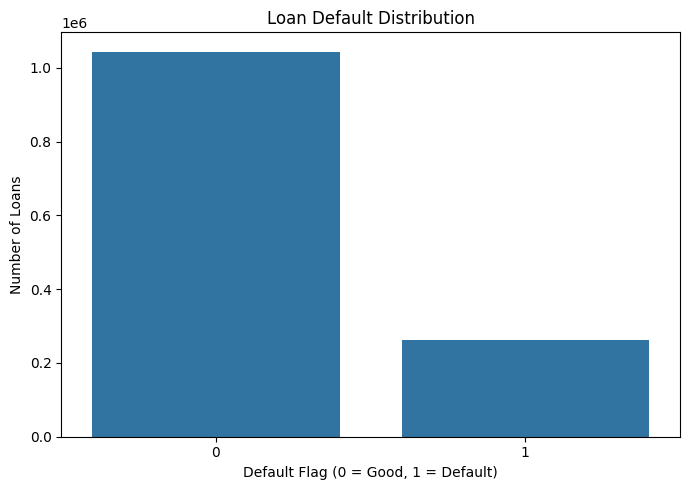

In [155]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x="default_flag"
)

plt.title("Loan Default Distribution")
plt.xlabel("Default Flag (0 = Good, 1 = Default)")
plt.ylabel("Number of Loans")

plt.tight_layout()
plt.show()

In [156]:
grade_default_rate = (
    df_clean.groupby("grade")["default_flag"]
    .agg(["count", "mean"])
    .sort_index()
)

grade_default_rate["default_rate_pct"] = (
    grade_default_rate["mean"] * 100
)

grade_default_rate

,count,mean,default_rate_pct
grade,,,
A,226343,0.060863,6.086338
B,380512,0.134471,13.447145
C,370566,0.225112,22.511240
D,195979,0.304349,30.434894
E,92110,0.385691,38.569102
F,31732,0.452477,45.247699
G,9145,0.497977,49.797704


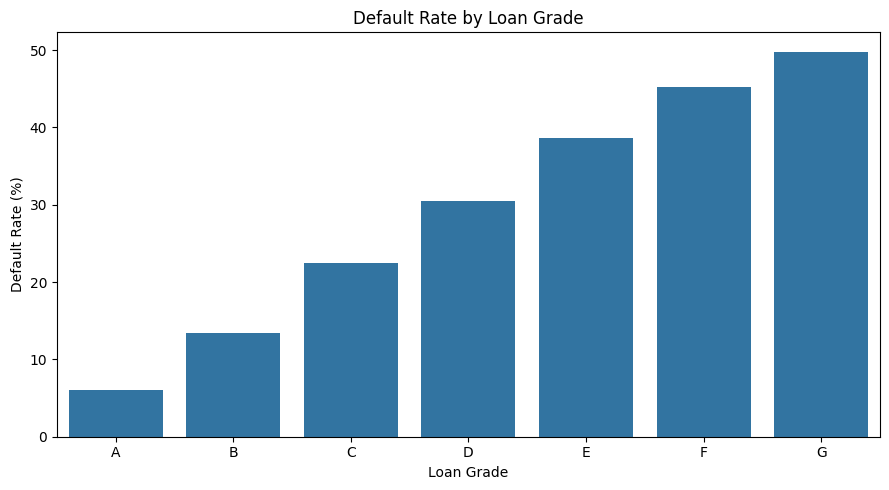

In [157]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=grade_default_rate.reset_index(),
    x="grade",
    y="default_rate_pct"
)

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [158]:
df_clean.groupby("default_flag")["int_rate"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
default_flag,,,,,
0,1043940,12.643303,12.29,5.31,30.99
1,262447,15.708974,15.05,5.31,30.99


In [159]:
df_clean["int_rate_band"] = pd.cut(
    df_clean["int_rate"],
    bins=[0, 8, 12, 16, 20, 24, 30, 40],
    labels=[
        "0-8%",
        "8-12%",
        "12-16%",
        "16-20%",
        "20-24%",
        "24-30%",
        "30%+"
    ],
    include_lowest=True
)

interest_default_rate = (
    df_clean.groupby("int_rate_band", observed=True)["default_flag"]
    .agg(["count", "mean"])
)

interest_default_rate["default_rate_pct"] = (
    interest_default_rate["mean"] * 100
)

interest_default_rate

,count,mean,default_rate_pct
int_rate_band,,,
0-8%,200076,0.058638,5.863772
8-12%,369289,0.134331,13.433111
12-16%,411060,0.216187,21.618742
16-20%,221896,0.314116,31.411562
20-24%,65834,0.377723,37.772276
24-30%,33739,0.459083,45.908296
30%+,4493,0.486312,48.631204


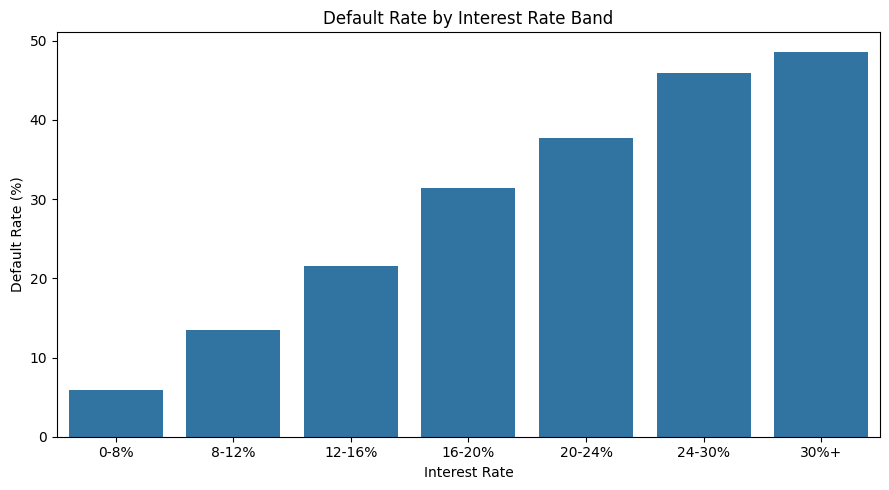

In [160]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=interest_default_rate.reset_index(),
    x="int_rate_band",
    y="default_rate_pct"
)

plt.title("Default Rate by Interest Rate Band")
plt.xlabel("Interest Rate")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [161]:
df_clean.groupby("default_flag")["dti"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
default_flag,,,,,
0,1043690,17.773911,17.09,-1.0,999.0
1,262385,20.144915,19.76,0.0,999.0


In [162]:
df_clean["dti_band"] = pd.cut(
    df_clean["dti"],
    bins=[-float("inf"), 10, 20, 30, 40, 50, float("inf")],
    labels=[
        "<10",
        "10-20",
        "20-30",
        "30-40",
        "40-50",
        "50+"
    ]
)

dti_default_rate = (
    df_clean.groupby("dti_band", observed=True)["default_flag"]
    .agg(["count", "mean"])
)

dti_default_rate["default_rate_pct"] = (
    dti_default_rate["mean"] * 100
)

dti_default_rate

,count,mean,default_rate_pct
dti_band,,,
<10,239489,0.149168,14.916760
10-20,546422,0.179671,17.967066
20-30,396677,0.232005,23.200488
30-40,117389,0.294031,29.403096
40-50,3609,0.339152,33.915212
50+,2489,0.286862,28.686219


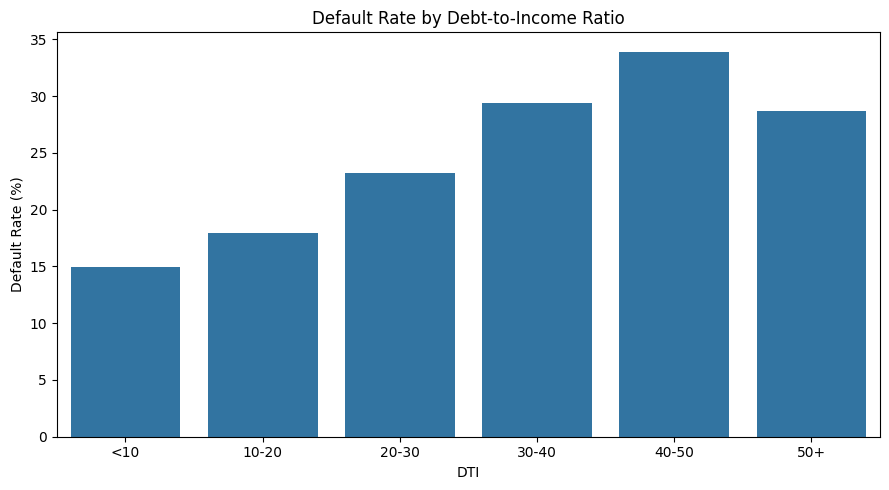

In [163]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=dti_default_rate.reset_index(),
    x="dti_band",
    y="default_rate_pct"
)

plt.title("Default Rate by Debt-to-Income Ratio")
plt.xlabel("DTI")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [164]:
print("DTI = -1:", (df_clean["dti"] == -1).sum())
print("DTI = 999:", (df_clean["dti"] == 999).sum())
print("DTI missing:", df_clean["dti"].isna().sum())

DTI = -1: 2
DTI = 999: 34
DTI missing: 312


In [165]:
for value in [-1, 999]:
    subset = df_clean[df_clean["dti"] == value]

    print(f"\nDTI = {value}")
    print("Loans:", len(subset))
    print(
        "Default rate:",
        round(subset["default_flag"].mean() * 100, 2),
        "%"
    )


DTI = -1
Loans: 2
Default rate: 0.0 %

DTI = 999
Loans: 34
Default rate: 20.59 %


In [166]:
# Treat invalid DTI values as missing
df_clean.loc[df_clean["dti"].isin([-1, 999]), "dti"] = pd.NA

In [167]:
df_clean["dti_band"] = pd.cut(
    df_clean["dti"],
    bins=[-float("inf"), 10, 20, 30, 40, 50, float("inf")],
    labels=[
        "<10",
        "10-20",
        "20-30",
        "30-40",
        "40-50",
        "50+"
    ]
)

dti_default_rate = (
    df_clean.groupby("dti_band", observed=True)["default_flag"]
    .agg(["count", "mean"])
)

dti_default_rate["default_rate_pct"] = (
    dti_default_rate["mean"] * 100
)

dti_default_rate

,count,mean,default_rate_pct
dti_band,,,
<10,239487,0.149169,14.916885
10-20,546422,0.179671,17.967066
20-30,396677,0.232005,23.200488
30-40,117389,0.294031,29.403096
40-50,3609,0.339152,33.915212
50+,2455,0.287984,28.798371


In [168]:
df_clean["annual_inc"].describe()

count    1.306383e+06
mean     7.614879e+04
std      7.004582e+04
min      0.000000e+00
25%      4.576000e+04
50%      6.500000e+04
75%      9.000000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

In [169]:
df_clean["income_band"] = pd.cut(
    df_clean["annual_inc"],
    bins=[0, 25000, 50000, 75000, 100000, 150000, 250000, float("inf")],
    labels=[
        "<25K",
        "25-50K",
        "50-75K",
        "75-100K",
        "100-150K",
        "150-250K",
        "250K+"
    ]
)

income_default_rate = (
    df_clean.groupby("income_band", observed=True)["default_flag"]
    .agg(["count", "mean"])
)

income_default_rate["default_rate_pct"] = (
    income_default_rate["mean"] * 100
)

income_default_rate

,count,mean,default_rate_pct
income_band,,,
<25K,49601,0.246810,24.680954
25-50K,370869,0.228641,22.864138
50-75K,400516,0.205977,20.597679
75-100K,243170,0.183316,18.331620
100-150K,173441,0.162499,16.249906
150-250K,55597,0.150835,15.083548
250K+,12887,0.132304,13.230387


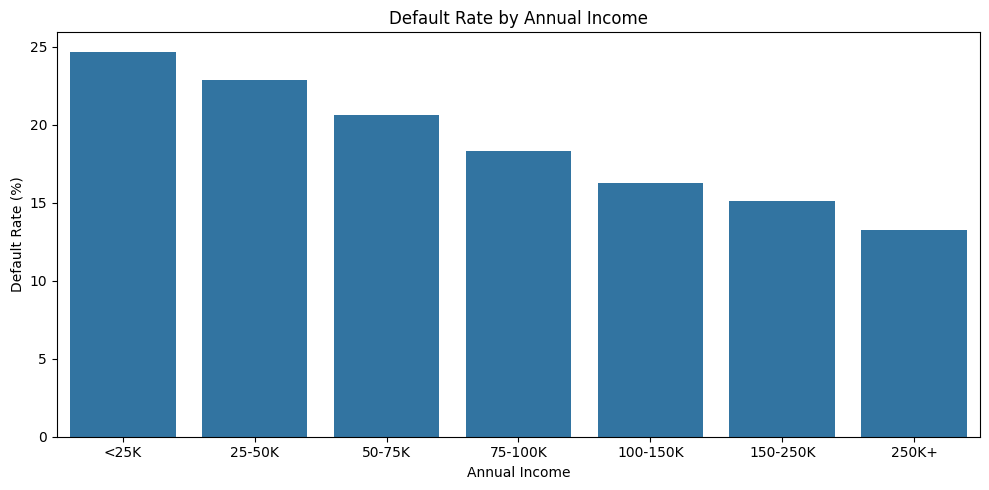

In [170]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=income_default_rate.reset_index(),
    x="income_band",
    y="default_rate_pct"
)

plt.title("Default Rate by Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [171]:
term_default_rate = (
    df_clean.groupby("term")["default_flag"]
    .agg(["count", "mean"])
)

term_default_rate["default_rate_pct"] = (
    term_default_rate["mean"] * 100
)

term_default_rate

,count,mean,default_rate_pct
term,,,
36 months,991212,0.161235,16.123493
60 months,315175,0.325625,32.562545


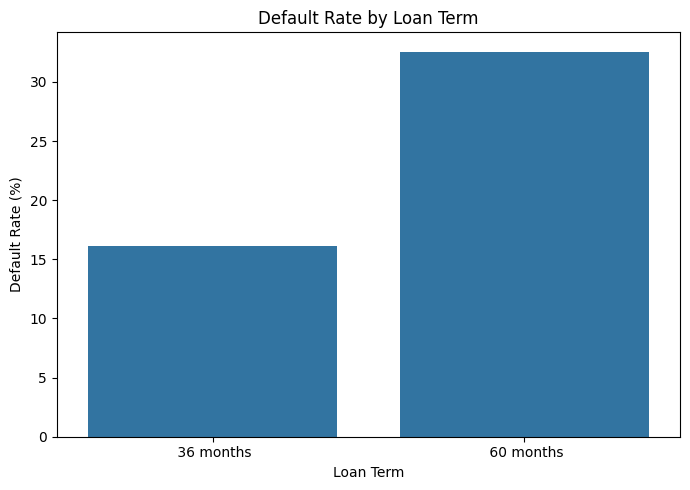

In [172]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=term_default_rate.reset_index(),
    x="term",
    y="default_rate_pct"
)

plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [173]:
home_default_rate = (
    df_clean.groupby("home_ownership")["default_flag"]
    .agg(["count", "mean"])
)

home_default_rate["default_rate_pct"] = (
    home_default_rate["mean"] * 100
)

home_default_rate

,count,mean,default_rate_pct
home_ownership,,,
ANY,267,0.194757,19.475655
MORTGAGE,646765,0.173205,17.320511
NONE,53,0.150943,15.094340
OTHER,182,0.208791,20.879121
OWN,140036,0.207554,20.755377
RENT,519084,0.233606,23.360574


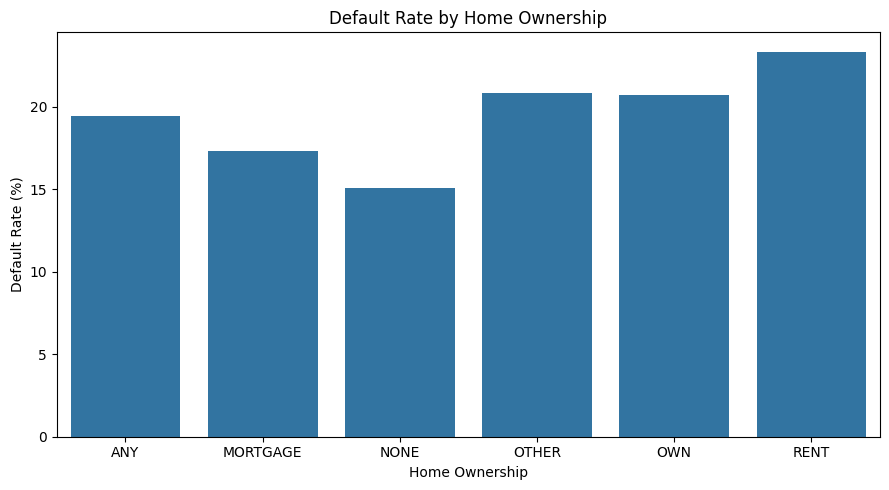

In [174]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=home_default_rate.reset_index(),
    x="home_ownership",
    y="default_rate_pct"
)

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [175]:
purpose_default_rate = (
    df_clean.groupby("purpose")["default_flag"]
    .agg(["count", "mean"])
)

purpose_default_rate["default_rate_pct"] = (
    purpose_default_rate["mean"] * 100
)

purpose_default_rate = purpose_default_rate.sort_values(
    "default_rate_pct",
    ascending=False
)

purpose_default_rate

,count,mean,default_rate_pct
purpose,,,
small_business,15171,0.299057,29.905741
renewable_energy,914,0.237418,23.741794
moving,9219,0.234950,23.494956
medical,15082,0.219732,21.973213
house,7011,0.217373,21.737270
debt_consolidation,758710,0.212664,21.266360
other,75361,0.212152,21.215217
educational,423,0.208038,20.803783
vacation,8751,0.192664,19.266370


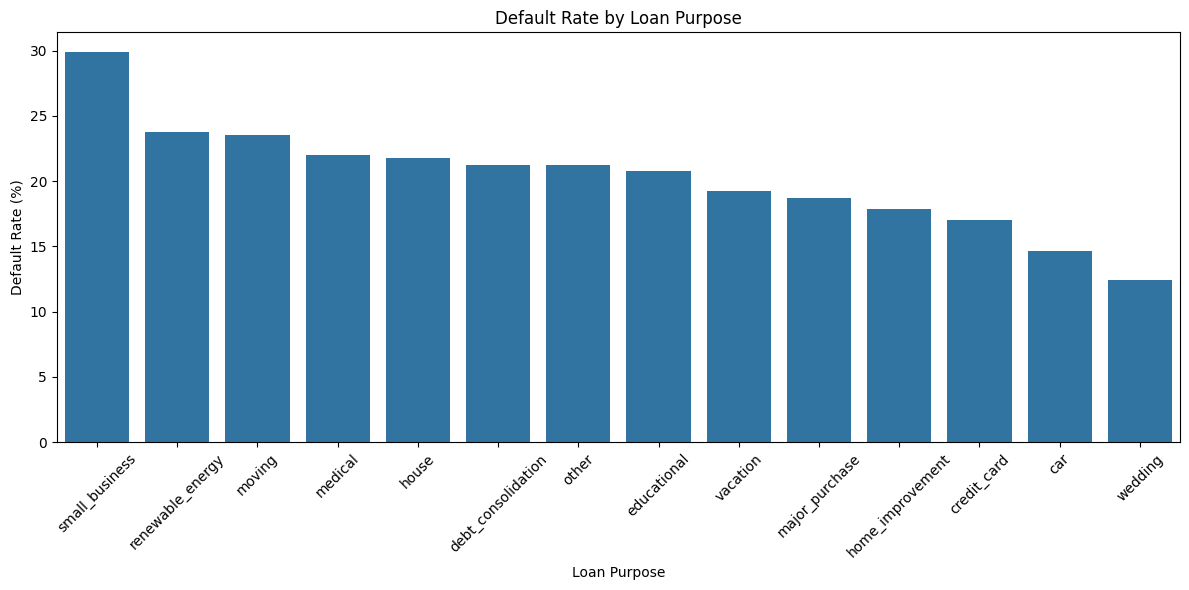

In [176]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=purpose_default_rate.reset_index(),
    x="purpose",
    y="default_rate_pct"
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [177]:
emp_default_rate = (
    df_clean.groupby("emp_length")["default_flag"]
    .agg(["count", "mean"])
)

emp_default_rate["default_rate_pct"] = (
    emp_default_rate["mean"] * 100
)

emp_default_rate

,count,mean,default_rate_pct
emp_length,,,
1 year,86026,0.206717,20.671657
10+ years,429023,0.189009,18.900851
2 years,118174,0.199409,19.940935
3 years,104470,0.201101,20.110079
4 years,78238,0.199162,19.916153
5 years,81795,0.197164,19.716364
6 years,61078,0.194866,19.486558
7 years,58248,0.196007,19.600673
8 years,59234,0.200831,20.083060


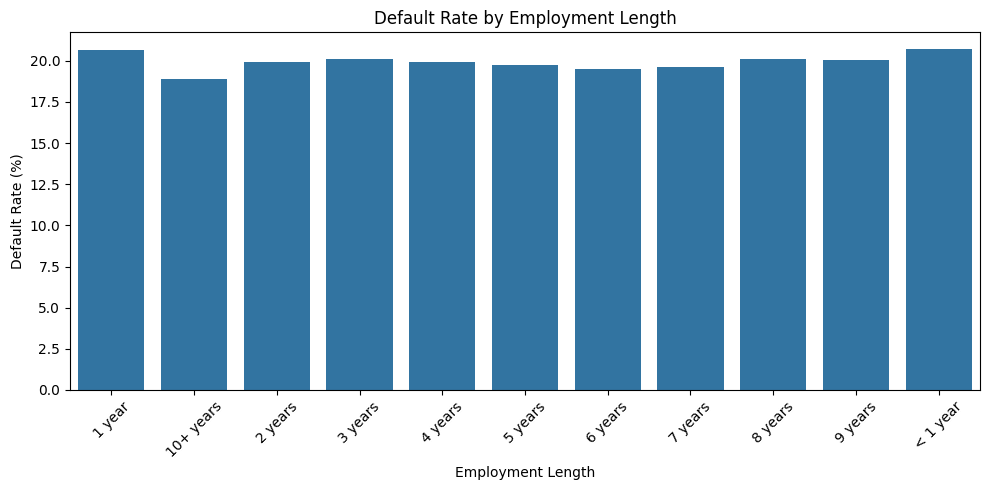

In [178]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=emp_default_rate.reset_index(),
    x="emp_length",
    y="default_rate_pct"
)

plt.title("Default Rate by Employment Length")
plt.xlabel("Employment Length")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [179]:
df_clean.groupby("default_flag")["revol_util"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
default_flag,,,,,
0,1043264,51.162123,51.4,0.0,892.3
1,262273,54.896732,55.7,0.0,366.6


In [180]:
df_clean["revol_util_band"] = pd.cut(
    df_clean["revol_util"],
    bins=[-float("inf"), 20, 40, 60, 80, 100, float("inf")],
    labels=[
        "<20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-100%",
        "100%+"
    ]
)

revol_util_default_rate = (
    df_clean.groupby(
        "revol_util_band",
        observed=True
    )["default_flag"]
    .agg(["count", "mean"])
)

revol_util_default_rate["default_rate_pct"] = (
    revol_util_default_rate["mean"] * 100
)

revol_util_default_rate

,count,mean,default_rate_pct
revol_util_band,,,
<20%,148744,0.149633,14.963293
20-40%,285378,0.180515,18.051497
40-60%,361556,0.206405,20.640509
60-80%,318154,0.219903,21.990294
80-100%,187141,0.228085,22.808471
100%+,4564,0.268843,26.884312


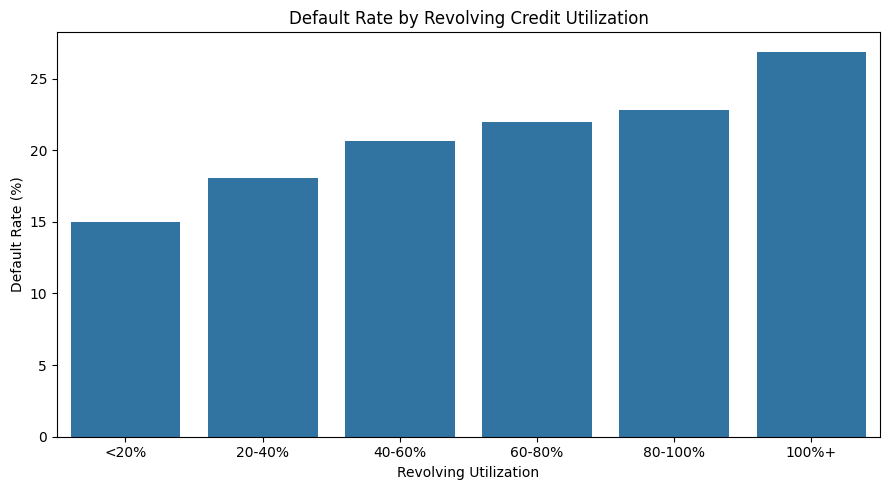

In [181]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=revol_util_default_rate.reset_index(),
    x="revol_util_band",
    y="default_rate_pct"
)

plt.title("Default Rate by Revolving Credit Utilization")
plt.xlabel("Revolving Utilization")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [182]:
df_clean["loan_amount_band"] = pd.cut(
    df_clean["loan_amnt"],
    bins=[0, 5000, 10000, 15000, 20000, 25000, 30000, 40000, float("inf")],
    labels=[
        "<5K",
        "5-10K",
        "10-15K",
        "15-20K",
        "20-25K",
        "25-30K",
        "30-40K",
        "40K+"
    ],
    include_lowest=True
)

loan_amount_default_rate = (
    df_clean.groupby(
        "loan_amount_band",
        observed=True
    )["default_flag"]
    .agg(["count", "mean"])
)

loan_amount_default_rate["default_rate_pct"] = (
    loan_amount_default_rate["mean"] * 100
)

loan_amount_default_rate

,count,mean,default_rate_pct
loan_amount_band,,,
<5K,176560,0.159793,15.979271
5-10K,362843,0.173226,17.322644
10-15K,276141,0.208712,20.871222
15-20K,208115,0.227538,22.753766
20-25K,129407,0.229176,22.917617
25-30K,74970,0.232880,23.287982
30-40K,78351,0.246021,24.602111


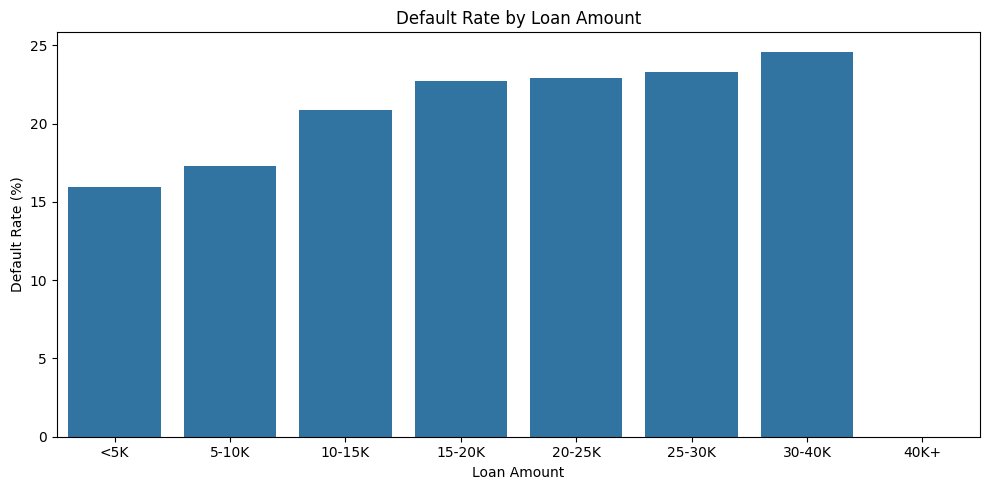

In [183]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=loan_amount_default_rate.reset_index(),
    x="loan_amount_band",
    y="default_rate_pct"
)

plt.title("Default Rate by Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

In [184]:
risk_numeric_cols = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "avg_cur_bal",
    "bc_open_to_buy",
    "bc_util",
    "delinq_amnt",
    "mort_acc",
    "num_accts_ever_120_pd",
    "num_actv_bc_tl",
    "num_actv_rev_tl",
    "num_bc_sats",
    "num_bc_tl",
    "num_il_tl",
    "num_op_rev_tl",
    "num_rev_accts",
    "num_rev_tl_bal_gt_0",
    "num_sats",
    "num_tl_120dpd_2m",
    "num_tl_30dpd",
    "num_tl_90g_dpd_24m",
    "pct_tl_nvr_dlq",
    "percent_bc_gt_75",
    "pub_rec_bankruptcies",
    "tax_liens",
    "tot_hi_cred_lim",
    "total_bal_ex_mort",
    "total_bc_limit",
    "total_il_high_credit_limit"
]

# Keep only columns that actually exist
risk_numeric_cols = [
    col for col in risk_numeric_cols
    if col in df_clean.columns
]

print("Number of numerical risk variables:", len(risk_numeric_cols))

Number of numerical risk variables: 43


In [185]:
correlation_matrix = df_clean[risk_numeric_cols].corr()

correlation_matrix

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,...,num_tl_30dpd,num_tl_90g_dpd_24m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
loan_amnt,1.000000,0.999529,0.998151,0.143566,0.953386,0.310283,0.034447,-0.002860,-0.019507,0.186642,...,0.002608,-0.022484,0.090104,0.021249,-0.095083,0.007373,0.335900,0.276317,0.373148,0.199706
funded_amnt,0.999529,1.000000,0.998734,0.143660,0.954080,0.310170,0.034920,-0.002657,-0.019902,0.186961,...,0.002608,-0.022486,0.090104,0.021247,-0.094879,0.007513,0.335899,0.276317,0.373156,0.199702
funded_amnt_inv,0.998151,0.998734,1.000000,0.143737,0.952644,0.309615,0.036222,-0.002340,-0.022864,0.187396,...,0.002597,-0.022500,0.090119,0.021197,-0.094489,0.007825,0.335928,0.276326,0.373191,0.199707
int_rate,0.143566,0.143660,0.143737,1.000000,0.155293,-0.071125,0.165404,0.048229,0.212544,-0.003785,...,0.014385,0.026610,-0.063071,0.250571,0.058907,0.012100,-0.118884,0.003469,-0.228903,-0.004485
installment,0.953386,0.954080,0.952644,0.155293,1.000000,0.301100,0.038449,0.006554,0.002667,0.176883,...,0.005004,-0.016968,0.072469,0.040703,-0.087123,0.014327,0.303030,0.260771,0.340755,0.184797
annual_inc,0.310283,0.310170,0.309615,-0.071125,0.301100,1.000000,-0.155950,0.040566,0.031578,0.133994,...,0.012129,0.007687,-0.006885,-0.017459,-0.044353,0.037326,0.409027,0.314663,0.268047,0.260809
dti,0.034447,0.034920,0.036222,0.165404,0.038449,-0.155950,1.000000,-0.007885,-0.009961,0.258252,...,0.005656,-0.015252,0.083332,0.147948,-0.020757,-0.025450,0.015413,0.258669,0.030299,0.291851
delinq_2yrs,-0.002860,-0.002657,-0.002340,0.048229,0.006554,0.040566,-0.007885,1.000000,0.022979,0.052465,...,0.104716,0.655952,-0.444705,-0.011123,-0.046873,0.011344,0.058544,0.031804,-0.075721,0.062247
inq_last_6mths,-0.019507,-0.019902,-0.022864,0.212544,0.002667,0.031578,-0.009961,0.022979,1.000000,0.129112,...,-0.006047,0.032103,-0.033374,-0.066407,0.073186,0.008621,0.030396,0.036479,-0.005139,0.044750
open_acc,0.186642,0.186961,0.187396,-0.003785,0.176883,0.133994,0.258252,0.052465,0.129112,1.000000,...,0.018000,0.011073,0.109198,-0.097013,-0.023041,-0.004082,0.280592,0.399560,0.358419,0.361448


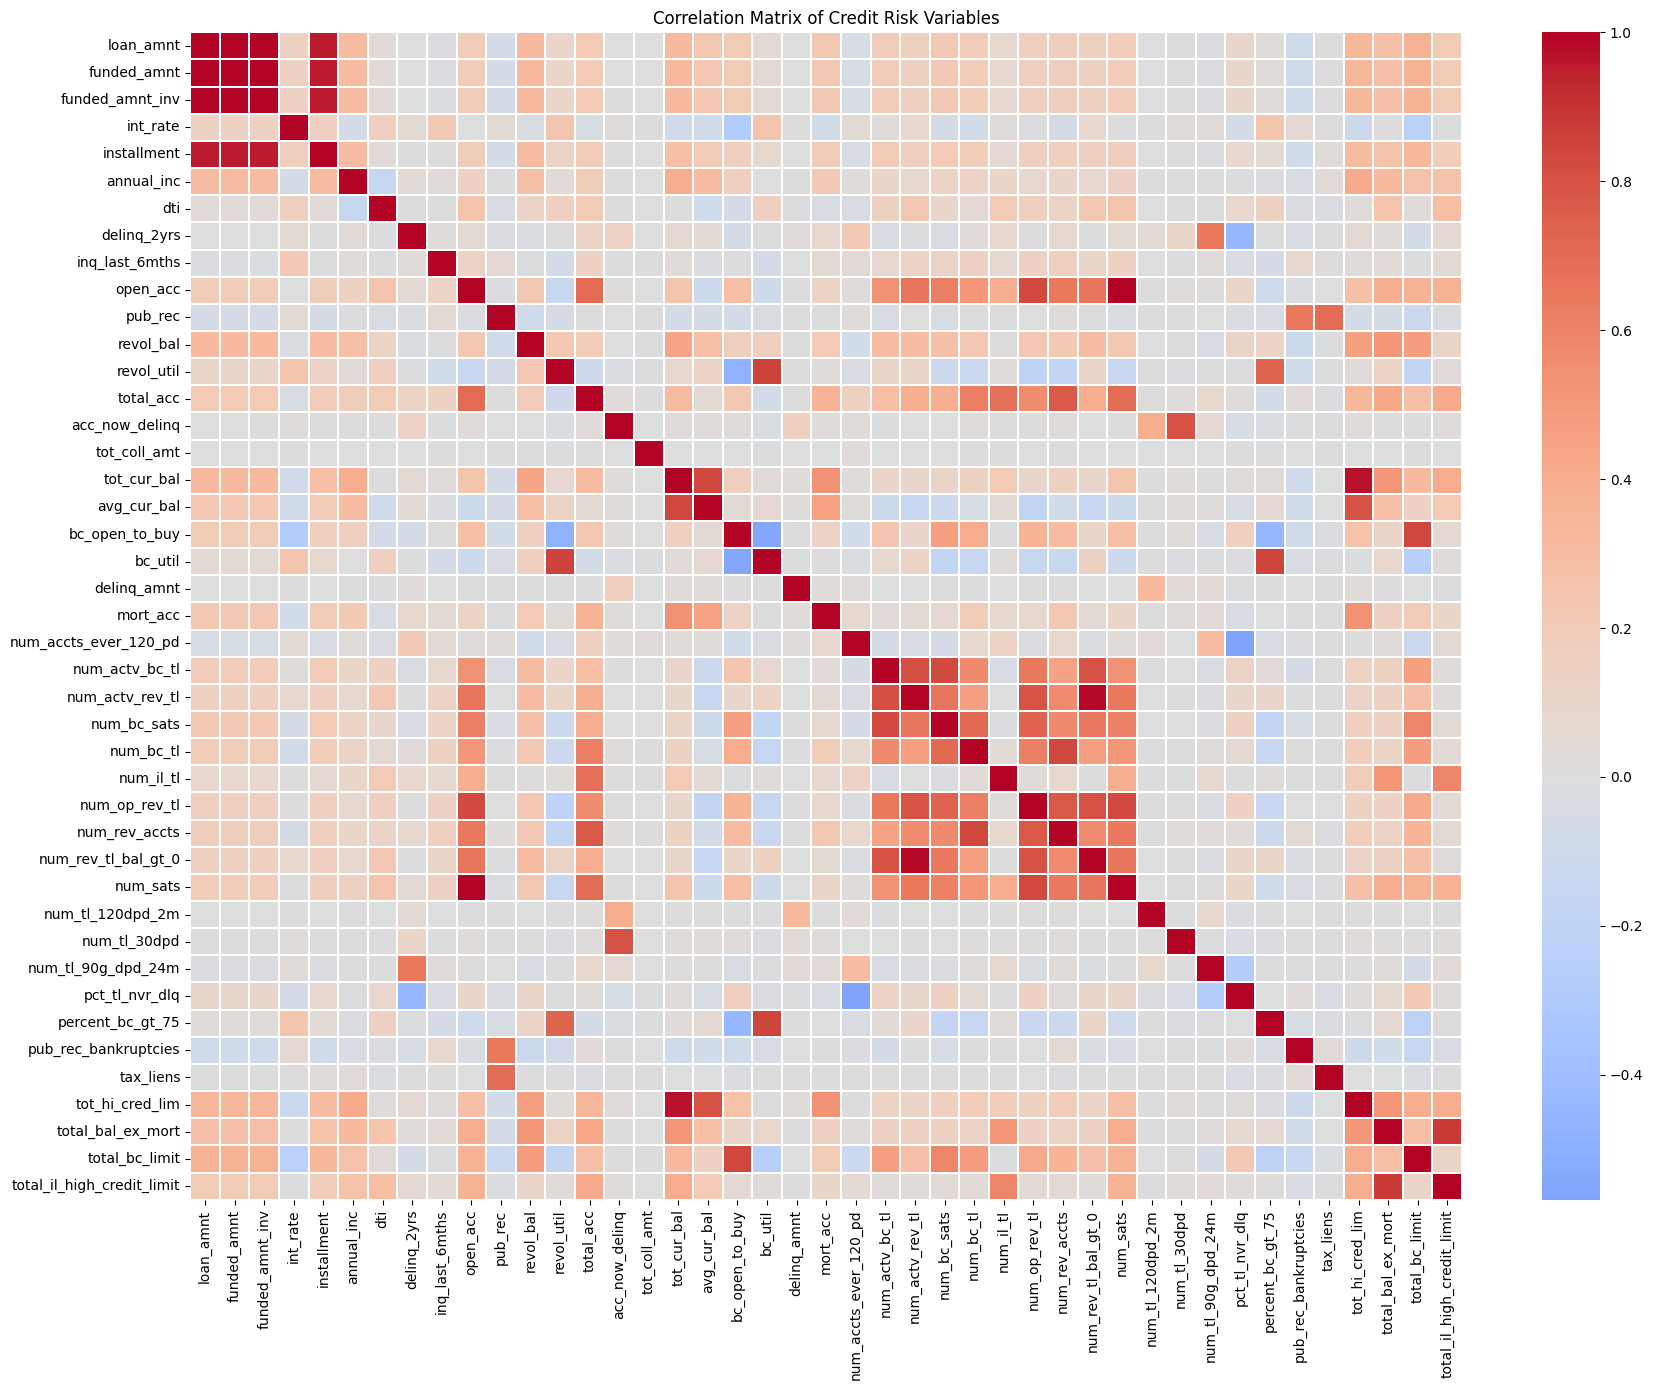

In [186]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Matrix of Credit Risk Variables")
plt.tight_layout()
plt.show()

In [187]:
corr_pairs = (
    correlation_matrix
    .where(
        ~np.eye(correlation_matrix.shape[0], dtype=bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Variable_1", "Variable_2", "Correlation"]

high_corr_pairs = corr_pairs[
    (corr_pairs["Correlation"].abs() >= 0.80)
    & (
        corr_pairs["Variable_1"] <
        corr_pairs["Variable_2"]
    )
].sort_values(
    "Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

high_corr_pairs

,Variable_1,Variable_2,Correlation
43,funded_amnt,loan_amnt,0.999529
45,funded_amnt,funded_amnt_inv,0.998734
1342,num_sats,open_acc,0.998717
86,funded_amnt_inv,loan_amnt,0.998151
1062,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.982017
727,tot_cur_bal,tot_hi_cred_lim,0.973521
47,funded_amnt,installment,0.954080
172,installment,loan_amnt,0.953386
90,funded_amnt_inv,installment,0.952644
1762,total_bal_ex_mort,total_il_high_credit_limit,0.872264


In [188]:
print("=" * 70)
print("PHASE 2 — CREDIT RISK EDA SUMMARY")
print("=" * 70)

print("\n1. OVERALL PORTFOLIO")
print(f"Total loans: {len(df_clean):,}")
print(f"Good loans: {(df_clean['default_flag'] == 0).sum():,}")
print(f"Bad loans: {(df_clean['default_flag'] == 1).sum():,}")
print(
    f"Default rate: "
    f"{df_clean['default_flag'].mean() * 100:.2f}%"
)

print("\n2. DEFAULT RATE BY GRADE")
print(
    grade_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n3. DEFAULT RATE BY INTEREST RATE")
print(
    interest_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n4. DEFAULT RATE BY DTI")
print(
    dti_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n5. DEFAULT RATE BY LOAN TERM")
print(
    term_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n6. DEFAULT RATE BY HOME OWNERSHIP")
print(
    home_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n7. DEFAULT RATE BY LOAN PURPOSE")
print(
    purpose_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n8. DEFAULT RATE BY EMPLOYMENT LENGTH")
print(
    emp_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n9. DEFAULT RATE BY REVOLVING UTILIZATION")
print(
    revol_util_default_rate[
        ["count", "default_rate_pct"]
    ]
)

print("\n10. DEFAULT RATE BY LOAN AMOUNT")
print(
    loan_amount_default_rate[
        ["count", "default_rate_pct"]
    ]
)

PHASE 2 — CREDIT RISK EDA SUMMARY

1. OVERALL PORTFOLIO
Total loans: 1,306,387
Good loans: 1,043,940
Bad loans: 262,447
Default rate: 20.09%

2. DEFAULT RATE BY GRADE
        count  default_rate_pct
grade                          
A      226343          6.086338
B      380512         13.447145
C      370566         22.511240
D      195979         30.434894
E       92110         38.569102
F       31732         45.247699
G        9145         49.797704

3. DEFAULT RATE BY INTEREST RATE
                count  default_rate_pct
int_rate_band                          
0-8%           200076          5.863772
8-12%          369289         13.433111
12-16%         411060         21.618742
16-20%         221896         31.411562
20-24%          65834         37.772276
24-30%          33739         45.908296
30%+             4493         48.631204

4. DEFAULT RATE BY DTI
           count  default_rate_pct
dti_band                          
<10       239487         14.916885
10-20     546422      

In [189]:
df_clean["loan_to_income"] = (
    df_clean["loan_amnt"] / df_clean["annual_inc"]
)

In [190]:
df_clean["funded_to_income"] = (
    df_clean["funded_amnt"] / df_clean["annual_inc"]
)

In [191]:
df_clean["installment_to_income"] = (
    df_clean["installment"] / (df_clean["annual_inc"] / 12)
)

In [192]:
df_clean["adjusted_debt_burden"] = (
    df_clean["dti"] / 100
    + df_clean["installment_to_income"]
)

In [193]:
df_clean[
    [
        "loan_amnt",
        "annual_inc",
        "installment",
        "dti",
        "loan_to_income",
        "funded_to_income",
        "installment_to_income",
        "adjusted_debt_burden"
    ]
].describe()

,loan_amnt,annual_inc,installment,dti,loan_to_income,funded_to_income,installment_to_income,adjusted_debt_burden
count,1.306387e+06,1.306383e+06,1.306387e+06,1.306039e+06,1.306383e+06,1.306383e+06,1.306383e+06,1.306035e+06
mean,1.440552e+04,7.614879e+04,4.377787e+02,1.822473e+01,inf,inf,inf,2.619020e-01
std,8.698613e+03,7.004582e+04,2.610471e+02,9.721544e+00,NaN,NaN,NaN,1.313817e-01
min,5.000000e+02,0.000000e+00,4.930000e+00,0.000000e+00,1.714286e-04,1.714286e-04,6.912000e-05,4.356800e-04
25%,8.000000e+03,4.576000e+04,2.484800e+02,1.178000e+01,1.250000e-01,1.249351e-01,4.632833e-02,1.831238e-01
50%,1.200000e+04,6.500000e+04,3.754300e+02,1.760000e+01,2.000000e-01,2.000000e-01,7.227600e-02,2.539221e-01
75%,2.000000e+04,9.000000e+04,5.799100e+02,2.403000e+01,2.909091e-01,2.909091e-01,1.054491e-01,3.312678e-01
max,4.000000e+04,1.099920e+07,1.719830e+03,9.915700e+02,inf,inf,inf,2.168400e+01


In [194]:
df_clean["monthly_income"] = (
    df_clean["annual_inc"] / 12
)

In [195]:
df_clean["installment_income_pct"] = (
    df_clean["installment"] /
    df_clean["monthly_income"]
) * 100

In [196]:
df_clean["income_per_open_account"] = (
    df_clean["annual_inc"] /
    df_clean["open_acc"].replace(0, np.nan)
)

In [197]:
df_clean["revol_bal_to_income"] = (
    df_clean["revol_bal"] /
    df_clean["annual_inc"]
)

In [198]:
df_clean["total_bal_to_income"] = (
    df_clean["tot_cur_bal"] /
    df_clean["annual_inc"]
)

In [199]:
df_clean[
    [
        "annual_inc",
        "monthly_income",
        "installment",
        "installment_income_pct",
        "open_acc",
        "income_per_open_account",
        "revol_bal",
        "revol_bal_to_income",
        "tot_cur_bal",
        "total_bal_to_income"
    ]
].describe()

,annual_inc,monthly_income,installment,installment_income_pct,open_acc,income_per_open_account,revol_bal,revol_bal_to_income,tot_cur_bal,total_bal_to_income
count,1.306383e+06,1.306383e+06,1.306387e+06,1.306383e+06,1.306358e+06,1.306345e+06,1.306387e+06,1.306376e+06,1.236111e+06,1.236111e+06
mean,7.614879e+04,6.345733e+03,4.377787e+02,inf,1.158915e+01,7.722346e+03,1.625944e+04,inf,1.410796e+05,inf
std,7.004582e+04,5.837152e+03,2.610471e+02,NaN,5.466121e+00,8.673384e+03,2.244088e+04,NaN,1.573114e+05,NaN
min,0.000000e+00,0.000000e+00,4.930000e+00,6.912000e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.576000e+04,3.813333e+03,2.484800e+02,4.632833e+00,8.000000e+00,4.153846e+03,5.945000e+03,9.843195e-02,2.947100e+04,5.195367e-01
50%,6.500000e+04,5.416667e+03,3.754300e+02,7.227600e+00,1.100000e+01,6.125000e+03,1.113600e+04,1.795818e-01,8.033500e+04,1.242500e+00
75%,9.000000e+04,7.500000e+03,5.799100e+02,1.054491e+01,1.400000e+01,9.200000e+03,1.975100e+04,2.956867e-01,2.106485e+05,2.820611e+00
max,1.099920e+07,9.166000e+05,1.719830e+03,inf,9.000000e+01,3.000000e+06,2.904836e+06,inf,8.000078e+06,inf


In [200]:
df_clean["revol_util_ratio"] = (
    df_clean["revol_util"] / 100
)

In [201]:
df_clean["bc_util_ratio"] = (
    df_clean["bc_util"] / 100
)

In [202]:
df_clean["credit_availability_ratio"] = (
    df_clean["bc_open_to_buy"] /
    (df_clean["bc_open_to_buy"] + df_clean["total_bc_limit"])
)

In [203]:
df_clean["revol_balance_limit_ratio"] = (
    df_clean["revol_bal"] /
    df_clean["total_rev_hi_lim"].replace(0, np.nan)
)

In [204]:
df_clean["installment_balance_to_income"] = (
    df_clean["total_bal_il"] /
    df_clean["annual_inc"].replace(0, np.nan)
)

In [205]:
df_clean["combined_utilization_stress"] = (
    df_clean["revol_util_ratio"] +
    df_clean["bc_util_ratio"]
) / 2

In [206]:
df_clean[
    [
        "revol_util",
        "revol_util_ratio",
        "bc_util",
        "bc_util_ratio",
        "credit_availability_ratio",
        "revol_balance_limit_ratio",
        "installment_balance_to_income",
        "combined_utilization_stress"
    ]
].describe()

,revol_util,revol_util_ratio,bc_util,bc_util_ratio,credit_availability_ratio,revol_balance_limit_ratio,installment_balance_to_income,combined_utilization_stress
count,1.305537e+06,1.305537e+06,1.242251e+06,1.242251e+06,1.242590e+06,1.235540e+06,499275.000000,1.242251e+06
mean,5.191238e+01,5.191238e-01,6.007139e+01,6.007139e-01,2.566163e-01,5.222581e-01,1.143236,5.603302e-01
std,2.451072e+01,2.451072e-01,2.826008e+01,2.826008e-01,1.450156e-01,2.436657e-01,189.434763,2.529862e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,3.360000e+01,3.360000e-01,3.850000e+01,3.850000e-01,1.337386e-01,3.398683e-01,0.148192,3.700000e-01
50%,5.230000e+01,5.230000e-01,6.340000e+01,6.340000e-01,2.648283e-01,5.257143e-01,0.351148,5.845000e-01
75%,7.080000e+01,7.080000e-01,8.490000e+01,8.490000e-01,3.794816e-01,7.102864e-01,0.650000,7.670000e-01
max,8.923000e+02,8.923000e+00,3.396000e+02,3.396000e+00,5.000000e-01,8.923333e+00,88396.000000,2.199000e+00


In [207]:
df_clean["total_delinquency"] = (
    df_clean["delinq_2yrs"].fillna(0)
    + df_clean["num_tl_30dpd"].fillna(0)
    + df_clean["num_tl_90g_dpd_24m"].fillna(0)
    + df_clean["num_tl_120dpd_2m"].fillna(0)
)


# 2. Severe delinquency indicator
# Flags borrowers with serious recent delinquency
df_clean["severe_delinquency_flag"] = (
    (
        (df_clean["num_tl_90g_dpd_24m"].fillna(0) > 0)
        |
        (df_clean["num_tl_120dpd_2m"].fillna(0) > 0)
    )
).astype(int)


# 3. Public-record risk indicator
# Flags borrowers with any public-record related issue
df_clean["public_record_flag"] = (
    (
        df_clean["pub_rec"].fillna(0)
        + df_clean["pub_rec_bankruptcies"].fillna(0)
        + df_clean["tax_liens"].fillna(0)
    ) > 0
).astype(int)


# 4. Clean credit-history ratio
# pct_tl_nvr_dlq is stored as a percentage
df_clean["clean_credit_history_ratio"] = (
    df_clean["pct_tl_nvr_dlq"] / 100
)


# 5. Credit inquiry intensity
# Recent inquiries relative to total credit accounts
df_clean["inquiry_intensity"] = (
    df_clean["inq_last_6mths"]
    / df_clean["total_acc"].replace(0, np.nan)
)


# 6. Average credit age
# Average age of revolving and installment credit histories
df_clean["avg_credit_age_months"] = (
    df_clean[
        [
            "mo_sin_old_rev_tl_op",
            "mo_sin_old_il_acct"
        ]
    ].mean(axis=1)
)



new_features = [
    "total_delinquency",
    "severe_delinquency_flag",
    "public_record_flag",
    "clean_credit_history_ratio",
    "inquiry_intensity",
    "avg_credit_age_months"
]

print("New features created:")
print(new_features)

print("\nFeature summary:")
print(
    df_clean[new_features].describe()
)

New features created:
['total_delinquency', 'severe_delinquency_flag', 'public_record_flag', 'clean_credit_history_ratio', 'inquiry_intensity', 'avg_credit_age_months']

Feature summary:
       total_delinquency  severe_delinquency_flag  public_record_flag  \
count       1.306387e+06             1.306387e+06        1.306387e+06   
mean        4.056179e-01             5.432158e-02        1.694429e-01   
std         1.260327e+00             2.266512e-01        3.751428e-01   
min         0.000000e+00             0.000000e+00        0.000000e+00   
25%         0.000000e+00             0.000000e+00        0.000000e+00   
50%         0.000000e+00             0.000000e+00        0.000000e+00   
75%         0.000000e+00             0.000000e+00        0.000000e+00   
max         7.800000e+01             1.000000e+00        1.000000e+00   

       clean_credit_history_ratio  inquiry_intensity  avg_credit_age_months  
count                1.235957e+06       1.306357e+06           1.236111e+06  

In [208]:

# 1. Revolving account ratio
# Proportion of total accounts that are revolving accounts
df_clean["revolving_account_ratio"] = (
    df_clean["num_rev_accts"]
    / df_clean["total_acc"].replace(0, np.nan)
)


# 2. Installment account ratio
# Proportion of total accounts that are installment accounts
df_clean["installment_account_ratio"] = (
    df_clean["num_il_tl"]
    / df_clean["total_acc"].replace(0, np.nan)
)


# 3. Active revolving account ratio
# Proportion of revolving accounts that are currently active
df_clean["active_revolving_ratio"] = (
    df_clean["num_actv_rev_tl"]
    / df_clean["num_rev_accts"].replace(0, np.nan)
)


# 4. Active bankcard ratio
# Proportion of bankcard accounts that are active
df_clean["active_bankcard_ratio"] = (
    df_clean["num_actv_bc_tl"]
    / df_clean["num_bc_tl"].replace(0, np.nan)
)


# 5. Open account ratio
# Proportion of total credit accounts that are currently open
df_clean["open_account_ratio"] = (
    df_clean["open_acc"]
    / df_clean["total_acc"].replace(0, np.nan)
)


# 6. Credit account diversity
# Measures the mix of revolving, installment and mortgage accounts
df_clean["account_diversity_ratio"] = (
    (
        df_clean["num_rev_accts"].fillna(0)
        + df_clean["num_il_tl"].fillna(0)
        + df_clean["mort_acc"].fillna(0)
    )
    / df_clean["total_acc"].replace(0, np.nan)
)



new_features = [
    "revolving_account_ratio",
    "installment_account_ratio",
    "active_revolving_ratio",
    "active_bankcard_ratio",
    "open_account_ratio",
    "account_diversity_ratio"
]

print("New features created:")
print(new_features)

print("\nFeature summary:")
print(
    df_clean[new_features].describe()
)

New features created:
['revolving_account_ratio', 'installment_account_ratio', 'active_revolving_ratio', 'active_bankcard_ratio', 'open_account_ratio', 'account_diversity_ratio']

Feature summary:
       revolving_account_ratio  installment_account_ratio  \
count             1.236110e+06               1.236111e+06   
mean              5.981096e-01               3.254083e-01   
std               1.887707e-01               1.882080e-01   
min               0.000000e+00               0.000000e+00   
25%               4.651163e-01               1.818182e-01   
50%               6.052632e-01               3.000000e-01   
75%               7.368421e-01               4.482759e-01   
max               1.000000e+00               1.000000e+00   

       active_revolving_ratio  active_bankcard_ratio  open_account_ratio  \
count            1.236109e+06           1.233329e+06        1.306358e+06   
mean             4.357589e-01           5.123185e-01        5.017338e-01   
std              2.137635

In [209]:

grade_mapping = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7
}

df_clean["grade_numeric"] = (
    df_clean["grade"].map(grade_mapping)
)


# 2. Funding ratio
# Measures how much of the requested loan amount was actually funded
df_clean["funding_ratio"] = (
    df_clean["funded_amnt"]
    / df_clean["loan_amnt"].replace(0, np.nan)
)


# 3. Investor funding ratio
# Measures investor-funded amount relative to total funded amount
df_clean["investor_funding_ratio"] = (
    df_clean["funded_amnt_inv"]
    / df_clean["funded_amnt"].replace(0, np.nan)
)


# 4. Interest-rate × loan-to-income interaction
# Captures pricing combined with borrower leverage
df_clean["interest_burden_proxy"] = (
    df_clean["int_rate"]
    * df_clean["loan_to_income"]
)


# 5. Interest-rate risk band
# Useful for risk segmentation and EDA
df_clean["interest_rate_risk_band"] = pd.cut(
    df_clean["int_rate"],
    bins=[0, 8, 12, 16, 20, 24, 30, float("inf")],
    labels=[
        "Very_Low",
        "Low",
        "Moderate",
        "Elevated",
        "High",
        "Very_High",
        "Extreme"
    ],
    include_lowest=True
)


new_features = [
    "grade_numeric",
    "funding_ratio",
    "investor_funding_ratio",
    "interest_burden_proxy",
    "interest_rate_risk_band"
]

print("New features created:")
print(new_features)

print("\nNumerical feature summary:")
print(
    df_clean[
        [
            "grade_numeric",
            "funding_ratio",
            "investor_funding_ratio",
            "interest_burden_proxy"
        ]
    ].describe()
)

print("\nInterest-rate risk bands:")
print(
    df_clean["interest_rate_risk_band"]
    .value_counts(dropna=False)
    .sort_index()
)

New features created:
['grade_numeric', 'funding_ratio', 'investor_funding_ratio', 'interest_burden_proxy', 'interest_rate_risk_band']

Numerical feature summary:
       grade_numeric  funding_ratio  investor_funding_ratio  \
count   1.306387e+06   1.306387e+06            1.306387e+06   
mean    2.754113e+00   9.995150e-01            9.974473e-01   
std     1.298655e+00   1.320144e-02            3.641607e-02   
min     1.000000e+00   1.012500e-01            0.000000e+00   
25%     2.000000e+00   1.000000e+00            1.000000e+00   
50%     3.000000e+00   1.000000e+00            1.000000e+00   
75%     4.000000e+00   1.000000e+00            1.000000e+00   
max     7.000000e+00   1.000000e+00            1.000000e+00   

       interest_burden_proxy  
count           1.306383e+06  
mean                     inf  
std                      NaN  
min             2.192571e-03  
25%             1.319500e+00  
50%             2.357419e+00  
75%             4.052070e+00  
max                  

In [210]:
emp_length_mapping = {
    "< 1 year": 0.5,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
}

df_clean["employment_years"] = (
    df_clean["emp_length"].map(emp_length_mapping)
)


# 2. Employment stability category
df_clean["employment_stability"] = pd.cut(
    df_clean["employment_years"],
    bins=[-np.inf, 1, 3, 5, 10, np.inf],
    labels=[
        "Very_Low",
        "Low",
        "Moderate",
        "High",
        "Very_High"
    ]
)


# 3. Income relative to employment tenure
df_clean["income_per_employment_year"] = (
    df_clean["annual_inc"]
    / df_clean["employment_years"].replace(0, np.nan)
)


# 4. Income verification indicator
df_clean["income_verified_flag"] = (
    df_clean["verification_status"]
    .astype(str)
    .str.lower()
    .str.contains("verified")
    .astype(int)
)


new_features = [
    "employment_years",
    "employment_stability",
    "income_per_employment_year",
    "income_verified_flag"
]

print("New features created:")
print(new_features)

print("\nNumerical feature summary:")
print(
    df_clean[
        [
            "employment_years",
            "income_per_employment_year",
            "income_verified_flag"
        ]
    ].describe()
)

print("\nEmployment stability distribution:")
print(
    df_clean["employment_stability"]
    .value_counts(dropna=False)
    .sort_index()
)

New features created:
['employment_years', 'employment_stability', 'income_per_employment_year', 'income_verified_flag']

Numerical feature summary:
       employment_years  income_per_employment_year  income_verified_flag
count      1.230896e+06                1.230892e+06             1306387.0
mean       6.007659e+00                2.977001e+04                   1.0
std        3.623253e+00                5.319118e+04                   0.0
min        5.000000e-01                0.000000e+00                   1.0
25%        2.000000e+00                7.200000e+03                   1.0
50%        6.000000e+00                1.200000e+04                   1.0
75%        1.000000e+01                2.800000e+04                   1.0
max        1.000000e+01                1.099920e+07                   1.0

Employment stability distribution:
employment_stability
Very_Low     191050
Low          222644
Moderate     160033
High         657169
Very_High         0
NaN           75491
Name: co

In [211]:
# 1. Convert issue date into datetime
df_clean["issue_date"] = pd.to_datetime(
    df_clean["issue_d"],
    format="%b-%Y",
    errors="coerce"
)


# 2. Origination year
df_clean["issue_year"] = (
    df_clean["issue_date"].dt.year
)


# 3. Origination month
df_clean["issue_month"] = (
    df_clean["issue_date"].dt.month
)


# 4. Origination quarter
df_clean["issue_quarter"] = (
    df_clean["issue_date"].dt.quarter
)


# 5. Loan vintage
# Each loan is assigned to its origination year
df_clean["loan_vintage"] = (
    df_clean["issue_year"].astype("Int64").astype(str)
)


# 6. Cyclical representation of origination month
# Helps models capture seasonal patterns without treating
# December and January as far apart.
df_clean["issue_month_sin"] = (
    np.sin(2 * np.pi * df_clean["issue_month"] / 12)
)

df_clean["issue_month_cos"] = (
    np.cos(2 * np.pi * df_clean["issue_month"] / 12)
)



new_features = [
    "issue_date",
    "issue_year",
    "issue_month",
    "issue_quarter",
    "loan_vintage",
    "issue_month_sin",
    "issue_month_cos"
]

print("New features created:")
print(new_features)

print("\nOrigination year distribution:")
print(
    df_clean["issue_year"]
    .value_counts()
    .sort_index()
)

print("\nOrigination quarter distribution:")
print(
    df_clean["issue_quarter"]
    .value_counts()
    .sort_index()
)

New features created:
['issue_date', 'issue_year', 'issue_month', 'issue_quarter', 'loan_vintage', 'issue_month_sin', 'issue_month_cos']

Origination year distribution:
issue_year
2007       603
2008      2393
2009      5281
2010     12537
2011     21721
2012     53367
2013    134793
2014    221468
2015    373412
2016    274711
2017    158910
2018     47191
Name: count, dtype: int64

Origination quarter distribution:
issue_quarter
1    327075
2    306654
3    324889
4    347769
Name: count, dtype: int64


In [212]:

# 1. Interest rate × DTI
# Captures the combined effect of loan pricing and borrower
# debt burden.
df_clean["interest_dti_interaction"] = (
    df_clean["int_rate"]
    * (df_clean["dti"] / 100)
)


# 2. Grade × utilization
# Captures borrower risk grade together with credit utilization.
df_clean["grade_utilization_interaction"] = (
    df_clean["grade_numeric"]
    * df_clean["revol_util_ratio"]
)


# 3. Grade × DTI
# Combines the lender-assigned risk grade with debt burden.
df_clean["grade_dti_interaction"] = (
    df_clean["grade_numeric"]
    * (df_clean["dti"] / 100)
)


# 4. Loan amount × interest rate
# Captures the interaction between exposure size and pricing.
df_clean["loan_rate_interaction"] = (
    df_clean["loan_amnt"]
    * df_clean["int_rate"]
)


# 5. Income × utilization stress
# Higher income may provide greater capacity to handle
# the same level of credit utilization.
df_clean["income_utilization_interaction"] = (
    np.log1p(df_clean["annual_inc"])
    * df_clean["combined_utilization_stress"]
)


# 6. Delinquency × utilization
# Combines past repayment problems with current credit usage.
df_clean["delinquency_utilization_interaction"] = (
    df_clean["total_delinquency"]
    * df_clean["combined_utilization_stress"]
)


# 7. DTI × utilization
# Captures combined debt burden and credit utilization stress.
df_clean["dti_utilization_interaction"] = (
    (df_clean["dti"] / 100)
    * df_clean["combined_utilization_stress"]
)


new_features = [
    "interest_dti_interaction",
    "grade_utilization_interaction",
    "grade_dti_interaction",
    "loan_rate_interaction",
    "income_utilization_interaction",
    "delinquency_utilization_interaction",
    "dti_utilization_interaction"
]

print("New interaction features created:")
print(new_features)

print("\nFeature summary:")
print(
    df_clean[new_features].describe()
)

New interaction features created:
['interest_dti_interaction', 'grade_utilization_interaction', 'grade_dti_interaction', 'loan_rate_interaction', 'income_utilization_interaction', 'delinquency_utilization_interaction', 'dti_utilization_interaction']

Feature summary:
       interest_dti_interaction  grade_utilization_interaction  \
count              1.306039e+06                   1.305537e+06   
mean               2.492850e+00                   1.505523e+00   
std                1.831911e+00                   1.105967e+00   
min                0.000000e+00                   0.000000e+00   
25%                1.269384e+00                   6.400000e-01   
50%                2.127066e+00                   1.294000e+00   
75%                3.325140e+00                   2.118000e+00   
max                2.126918e+02                   1.784600e+01   

       grade_dti_interaction  loan_rate_interaction  \
count           1.306039e+06           1.306387e+06   
mean            5.227194e-0

In [216]:


engineered_features = [
    # Part 1
    "loan_to_income",
    "funded_to_income",
    "installment_to_income",
    "adjusted_debt_burden",

    # Part 2
    "monthly_income",
    "installment_income_pct",
    "income_per_open_account",
    "revol_bal_to_income",
    "total_bal_to_income",

    # Part 3
    "revol_util_ratio",
    "bc_util_ratio",
    "credit_availability_ratio",
    "revol_balance_limit_ratio",
    "installment_balance_to_income",
    "combined_utilization_stress",

    # Part 4
    "total_delinquency",
    "severe_delinquency_flag",
    "public_record_flag",
    "clean_credit_history_ratio",
    "inquiry_intensity",
    "avg_credit_age_months",

    # Part 5
    "revolving_account_ratio",
    "installment_account_ratio",
    "active_revolving_ratio",
    "active_bankcard_ratio",
    "open_account_ratio",
    "account_diversity_ratio",

    # Part 6
    "grade_numeric",
    "funding_ratio",
    "investor_funding_ratio",
    "interest_burden_proxy",
    "interest_rate_risk_band",

    # Part 7
    "employment_years",
    "employment_stability",
    "income_per_employment_year",
    "income_verified_flag",

    # Part 8
    "issue_date",
    "issue_year",
    "issue_month",
    "issue_quarter",
    "loan_vintage",
    "issue_month_sin",
    "issue_month_cos",

    # Part 9
    "interest_dti_interaction",
    "grade_utilization_interaction",
    "grade_dti_interaction",
    "loan_rate_interaction",
    "income_utilization_interaction",
    "delinquency_utilization_interaction",
    "dti_utilization_interaction"
]

# Keep only features that actually exist
engineered_features = [
    col for col in engineered_features
    if col in df_clean.columns
]


print("\nEngineered features:")
print(engineered_features)



missing_summary = (
    df_clean[engineered_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    df_clean[engineered_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "Missing_Count": missing_summary,
    "Missing_Percentage": missing_percentage
})

print(
    missing_report[
        missing_report["Missing_Count"] > 0
    ]
)


numeric_engineered = (
    df_clean[engineered_features]
    .select_dtypes(include=np.number)
)

infinite_counts = np.isinf(
    numeric_engineered
).sum()



if infinite_counts.sum() == 0:
    print("No infinite values found.")
else:
    print(
        infinite_counts[
            infinite_counts > 0
        ]
    )



duplicate_columns = []

for i in range(len(engineered_features)):
    for j in range(i + 1, len(engineered_features)):
        
        col1 = engineered_features[i]
        col2 = engineered_features[j]

        if df_clean[col1].equals(df_clean[col2]):
            duplicate_columns.append(
                (col1, col2)
            )

if len(duplicate_columns) == 0:
    print("No duplicate engineered features found.")
else:
    for pair in duplicate_columns:
        print(pair)



numeric_summary = (
    df_clean[
        numeric_engineered.columns
    ]
    .describe()
    .T
)
print(
    numeric_summary[
        ["min", "max"]
    ].sort_values("max", ascending=False).head(20)
)



leakage_keywords = [
    "recover",
    "collection",
    "settlement",
    "hardship",
    "payment",
    "pymnt",
    "total_pymnt",
    "total_rec",
    "out_prncp",
    "last_pymnt",
    "next_pymnt",
    "last_credit_pull",
    "debt_settlement"
]

potential_leakage = [
    col
    for col in df_clean.columns
    if any(
        keyword in col.lower()
        for keyword in leakage_keywords
    )
]
print("POTENTIAL LEAKAGE COLUMNS")
print(potential_leakage)


Engineered features:
['loan_to_income', 'funded_to_income', 'installment_to_income', 'adjusted_debt_burden', 'monthly_income', 'installment_income_pct', 'income_per_open_account', 'revol_bal_to_income', 'total_bal_to_income', 'revol_util_ratio', 'bc_util_ratio', 'credit_availability_ratio', 'revol_balance_limit_ratio', 'installment_balance_to_income', 'combined_utilization_stress', 'total_delinquency', 'severe_delinquency_flag', 'public_record_flag', 'clean_credit_history_ratio', 'inquiry_intensity', 'avg_credit_age_months', 'revolving_account_ratio', 'installment_account_ratio', 'active_revolving_ratio', 'active_bankcard_ratio', 'open_account_ratio', 'account_diversity_ratio', 'grade_numeric', 'funding_ratio', 'investor_funding_ratio', 'interest_burden_proxy', 'interest_rate_risk_band', 'employment_years', 'employment_stability', 'income_per_employment_year', 'income_verified_flag', 'issue_date', 'issue_year', 'issue_month', 'issue_quarter', 'loan_vintage', 'issue_month_sin', 'issue_

In [218]:
#Replace infinite values with NaN
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

df_clean[numeric_columns] = (
    df_clean[numeric_columns]
    .replace([np.inf, -np.inf], np.nan)
)

engineered_features = [
    # Part 1
    "loan_to_income",
    "funded_to_income",
    "installment_to_income",
    "adjusted_debt_burden",

    # Part 2
    "monthly_income",
    "installment_income_pct",
    "income_per_open_account",
    "revol_bal_to_income",
    "total_bal_to_income",

    # Part 3
    "revol_util_ratio",
    "bc_util_ratio",
    "credit_availability_ratio",
    "revol_balance_limit_ratio",
    "installment_balance_to_income",
    "combined_utilization_stress",

    # Part 4
    "total_delinquency",
    "severe_delinquency_flag",
    "public_record_flag",
    "clean_credit_history_ratio",
    "inquiry_intensity",
    "avg_credit_age_months",

    # Part 5
    "revolving_account_ratio",
    "installment_account_ratio",
    "active_revolving_ratio",
    "active_bankcard_ratio",
    "open_account_ratio",
    "account_diversity_ratio",

    # Part 6
    "grade_numeric",
    "funding_ratio",
    "investor_funding_ratio",
    "interest_burden_proxy",
    "interest_rate_risk_band",

    # Part 7
    "employment_years",
    "employment_stability",
    "income_per_employment_year",
    "income_verified_flag",

    # Part 8
    "issue_date",
    "issue_year",
    "issue_month",
    "issue_quarter",
    "loan_vintage",
    "issue_month_sin",
    "issue_month_cos",

    # Part 9
    "interest_dti_interaction",
    "grade_utilization_interaction",
    "grade_dti_interaction",
    "loan_rate_interaction",
    "income_utilization_interaction",
    "delinquency_utilization_interaction",
    "dti_utilization_interaction"
]

engineered_features = [
    col for col in engineered_features
    if col in df_clean.columns
]


remaining_infinite = np.isinf(
    df_clean.select_dtypes(include=np.number)
).sum().sum()


In [219]:
final_missing = (
    df_clean[engineered_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)



print(
    final_missing[
        final_missing > 0
    ]
)



print("\n" + "=" * 70)
print("TARGET CHECK")
print("=" * 70)

print(
    df_clean["default_flag"]
    .value_counts()
)

print("\nDefault rate:")
print(
    df_clean["default_flag"].mean() * 100,
    "%"
)


print("\n" + "=" * 70)
print("PHASE 3 COMPLETE")
print("=" * 70)

print(
    "Final dataset shape:",
    df_clean.shape
)

print(
    "Engineered features:",
    len(engineered_features)
)

print(
    "Total numerical columns:",
    len(
        df_clean.select_dtypes(
            include=np.number
        ).columns
    )
)

print(
    "Total categorical columns:",
    len(
        df_clean.select_dtypes(
            include=["object", "str", "category"]
        ).columns
    ))

installment_balance_to_income          807112
income_per_employment_year              75495
employment_stability                    75491
employment_years                        75491
active_bankcard_ratio                   73058
revol_balance_limit_ratio               70847
total_bal_to_income                     70578
clean_credit_history_ratio              70430
active_revolving_ratio                  70278
revolving_account_ratio                 70277
installment_account_ratio               70276
avg_credit_age_months                   70276
dti_utilization_interaction             64479
bc_util_ratio                           64136
income_utilization_interaction          64136
delinquency_utilization_interaction     64136
combined_utilization_stress             64136
credit_availability_ratio               63797
grade_utilization_interaction             850
revol_util_ratio                          850
adjusted_debt_burden                      352
interest_dti_interaction          

In [220]:
target = "default_flag"


X = df_clean.drop(columns=[target]).copy()
y = df_clean[target].copy()

In [221]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1306387, 145)
y shape: (1306387,)


In [222]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
default_flag
0    1043940
1     262447
Name: count, dtype: int64


In [223]:
print("\nTarget percentage:")
print(
    y.value_counts(normalize=True).mul(100)
)


Target percentage:
default_flag
0    79.910471
1    20.089529
Name: proportion, dtype: float64


In [224]:
print("\nTarget missing values:")
print(y.isna().sum())


Target missing values:
0


In [225]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()



print("\nCategorical columns:")
print(categorical_features)


Categorical columns:
['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'disbursement_method', 'int_rate_band', 'dti_band', 'income_band', 'revol_util_band', 'loan_amount_band', 'interest_rate_risk_band', 'employment_stability', 'loan_vintage']


In [228]:
X_model = X.copy()
drop_columns = [
    "id",
    "member_id",
    "url",
    "desc","issue_d",
        "issue_date","policy_code"]


leakage_columns = [
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d",
    "hardship_flag",
    "hardship_type",
    "hardship_reason",
    "hardship_status",
    "hardship_amount",
    "hardship_start_date",
    "hardship_end_date",
    "payment_plan_start_date",
    "hardship_length",
    "hardship_dpd",
    "hardship_loan_status",
    "hardship_payoff_balance_amount",
    "hardship_last_payment_amount",
    "debt_settlement_flag",
    "debt_settlement_flag_date",
    "settlement_status",
    "settlement_date",
    "settlement_amount",
    "settlement_percentage",
    "settlement_term"
]

drop_columns += leakage_columns

drop_columns = [
    col for col in drop_columns
    if col in X_model.columns
]

X_model = X_model.drop(
    columns=drop_columns
)


numeric_features = X_model.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_model.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

In [230]:

train_mask = X_model["issue_year"] <= 2015
validation_mask = X_model["issue_year"] == 2016
test_mask = X_model["issue_year"] >= 2017


X_train = X_model.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X_model.loc[validation_mask].copy()
y_val = y.loc[validation_mask].copy()

X_test = X_model.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (825575, 142)
Validation set: (274711, 142)
Test set: (206101, 142)


In [231]:
print("\nTraining default rate:")
print(y_train.mean() * 100, "%")

print("\nValidation default rate:")
print(y_val.mean() * 100, "%")

print("\nTest default rate:")
print(y_test.mean() * 100, "%")



Training default rate:
18.463252884353327 %

Validation default rate:
24.27241719479744 %

Test default rate:
21.028524849467008 %


In [232]:

print(
    "Training years:",
    sorted(X_train["issue_year"].dropna().unique())
)

print(
    "Validation years:",
    sorted(X_val["issue_year"].dropna().unique())
)

print(
    "Test years:",
    sorted(X_test["issue_year"].dropna().unique())
)

Training years: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]
Validation years: [np.int32(2016)]
Test years: [np.int32(2017), np.int32(2018)]


In [233]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [234]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

In [235]:
#Numerical preprocessing
numeric_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="median"))])
# 3. Categorical preprocessing
categorical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),(
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True))])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [237]:

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)


In [239]:

print("Original training features:",
      X_train.shape[1])

print("Processed training features:",
      X_train_processed.shape[1])

print("Processed validation features:",
      X_val_processed.shape[1])

print("Processed test features:",
      X_test_processed.shape[1])

Original training features: 142
Processed training features: 350962
Processed validation features: 350962
Processed test features: 350962


In [240]:
categorical_features = X_train.select_dtypes(include=["object","str","category"]).columns.tolist()

cardinality = X_train[categorical_features].nunique(dropna=True).sort_values(ascending=False)

print("CATEGORICAL FEATURE CARDINALITY")

print(cardinality)


print("HIGH-CARDINALITY FEATURES (>100 UNIQUE VALUES)")
print(cardinality[cardinality > 100])

CATEGORICAL FEATURE CARDINALITY
emp_title                  285878
title                       63147
zip_code                      933
earliest_cr_line              697
addr_state                     51
sub_grade                      35
purpose                        14
emp_length                     11
loan_vintage                    9
grade                           7
income_band                     7
loan_amount_band                7
revol_util_band                 6
dti_band                        6
interest_rate_risk_band         6
home_ownership                  6
int_rate_band                   6
employment_stability            4
loan_status                     4
verification_status             3
term                            2
initial_list_status             2
application_type                2
disbursement_method             1
dtype: int64
HIGH-CARDINALITY FEATURES (>100 UNIQUE VALUES)
emp_title           285878
title                63147
zip_code               933
earliest_cr

In [242]:

high_cardinality_features = ["emp_title","title","zip_code","earliest_cr_line"]

X_model = X_model.drop(columns=[col for col in high_cardinality_features if col in X_model.columns])

X_train = X_model.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_val = X_model.loc[validation_mask].copy()
y_val = y.loc[validation_mask].copy()
X_test = X_model.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()


In [243]:

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training shape: (825575, 138)
Validation shape: (274711, 138)
Test shape: (206101, 138)


In [244]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object","str","category"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="median"))])

categorical_pipeline = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ("num",numeric_pipeline,numeric_features),
    ("cat",categorical_pipeline,categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [247]:
print("Original features:",X_train.shape[1])
print("Processed training features:",X_train_processed.shape[1])
print("Processed validation features:",X_val_processed.shape[1])
print("Processed test features:",X_test_processed.shape[1])

Original features: 138
Processed training features: 307
Processed validation features: 307
Processed test features: 307


In [248]:

print("Train shape:",X_train_processed.shape)
print("Validation shape:",X_val_processed.shape)
print("Test shape:",X_test_processed.shape)

print("\nTarget missing values:")
print("Train:",y_train.isna().sum())
print("Validation:",y_val.isna().sum())
print("Test:",y_test.isna().sum())

print("\nDefault rates:")
print("Train:",round(y_train.mean()*100,2),"%")
print("Validation:",round(y_val.mean()*100,2),"%")
print("Test:",round(y_test.mean()*100,2),"%")

print("\nTime ranges:")
print("Train:",X_train["issue_year"].min(),"-",X_train["issue_year"].max())
print("Validation:",X_val["issue_year"].min(),"-",X_val["issue_year"].max())
print("Test:",X_test["issue_year"].min(),"-",X_test["issue_year"].max())

print("\nProcessed feature counts:")
print("Train:",X_train_processed.shape[1])
print("Validation:",X_val_processed.shape[1])
print("Test:",X_test_processed.shape[1])


Train shape: (825575, 307)
Validation shape: (274711, 307)
Test shape: (206101, 307)

Target missing values:
Train: 0
Validation: 0
Test: 0

Default rates:
Train: 18.46 %
Validation: 24.27 %
Test: 21.03 %

Time ranges:
Train: 2007 - 2015
Validation: 2016 - 2016
Test: 2017 - 2018

Processed feature counts:
Train: 307
Validation: 307
Test: 307


In [249]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000,solver="lbfgs")
logistic_model.fit(X_train_processed,y_train)

y_train_pd = logistic_model.predict_proba(X_train_processed)[:,1]
y_val_pd = logistic_model.predict_proba(X_val_processed)[:,1]
y_test_pd = logistic_model.predict_proba(X_test_processed)[:,1]


In [250]:

print("\nPD range:")
print("Train:",y_train_pd.min(),"-",y_train_pd.max())
print("Validation:",y_val_pd.min(),"-",y_val_pd.max())
print("Test:",y_test_pd.min(),"-",y_test_pd.max())

print("\nMean predicted PD:")
print("Train:",round(y_train_pd.mean(),4))
print("Validation:",round(y_val_pd.mean(),4))
print("Test:",round(y_test_pd.mean(),4))


PD range:
Train: 8.929701513663142e-43 - 0.9803151969915825
Validation: 1.5640507915206183e-18 - 1.0
Test: 2.7429225229942692e-39 - 0.9999999999616218

Mean predicted PD:
Train: 0.1841
Validation: 0.2023
Test: 0.2078


In [252]:
# PD MODEL DISCRIMINATION
from sklearn.metrics import roc_auc_score,roc_curve
train_auc=roc_auc_score(y_train,y_train_pd)
val_auc=roc_auc_score(y_val,y_val_pd)
test_auc=roc_auc_score(y_test,y_test_pd)

train_gini=2*train_auc-1
val_gini=2*val_auc-1
test_gini=2*test_auc-1

def ks_statistic(y_true,pd_pred):
    fpr,tpr,thresholds=roc_curve(y_true,pd_pred)
    return np.max(tpr-fpr)

train_ks=ks_statistic(y_train,y_train_pd)
val_ks=ks_statistic(y_val,y_val_pd)
test_ks=ks_statistic(y_test,y_test_pd)

In [253]:
print("ROC-AUC")
print("Train:",round(train_auc,4))
print("Validation:",round(val_auc,4))
print("Test:",round(test_auc,4))

print("\nGini")
print("Train:",round(train_gini,4))
print("Validation:",round(val_gini,4))
print("Test:",round(test_gini,4))

print("\nKS Statistic")
print("Train:",round(train_ks,4))
print("Validation:",round(val_ks,4))
print("Test:",round(test_ks,4))

ROC-AUC
Train: 0.6926
Validation: 0.6678
Test: 0.6658

Gini
Train: 0.3852
Validation: 0.3356
Test: 0.3316

KS Statistic
Train: 0.2846
Validation: 0.2449
Test: 0.247


In [255]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score
threshold=0.5
y_test_pred=(y_test_pd>=threshold).astype(int)

cm=confusion_matrix(y_test,y_test_pred)
accuracy=accuracy_score(y_test,y_test_pred)
precision=precision_score(y_test,y_test_pred,zero_division=0)
recall=recall_score(y_test,y_test_pred,zero_division=0)
f1=f1_score(y_test,y_test_pred,zero_division=0)
print("Threshold:",threshold)

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:",round(accuracy,4))
print("Precision:",round(precision,4))
print("Recall:",round(recall,4))
print("F1 Score:",round(f1,4))

print("\nPredicted Non-Defaults:",(y_test_pred==0).sum())
print("Predicted Defaults:",(y_test_pred==1).sum())

Threshold: 0.5

Confusion Matrix:
[[155864   6897]
 [ 38579   4761]]

Accuracy: 0.7794
Precision: 0.4084
Recall: 0.1099
F1 Score: 0.1731

Predicted Non-Defaults: 194443
Predicted Defaults: 11658


In [256]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

train_brier=brier_score_loss(y_train,y_train_pd)
val_brier=brier_score_loss(y_val,y_val_pd)
test_brier=brier_score_loss(y_test,y_test_pd)

print("Brier Score")
print("Train:",round(train_brier,4))
print("Validation:",round(val_brier,4))
print("Test:",round(test_brier,4))

Brier Score
Train: 0.1409
Validation: 0.1774
Test: 0.1625


In [259]:
prob_true,prob_pred=calibration_curve(y_test,y_test_pd,n_bins=10,strategy="quantile")

print("\nCalibration Table")
print("Predicted PD | Actual Default Rate")

for p,a in zip(prob_pred,prob_true):
    print(round(p,4),"|",round(a,4))


Calibration Table
Predicted PD | Actual Default Rate
0.0588 | 0.0791
0.0997 | 0.0974
0.1222 | 0.124
0.1401 | 0.1553
0.1569 | 0.1861
0.1758 | 0.2219
0.2006 | 0.2492
0.2394 | 0.2842
0.3153 | 0.3174
0.5694 | 0.3884


In [260]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

train_brier=brier_score_loss(y_train,y_train_pd)
val_brier=brier_score_loss(y_val,y_val_pd)
test_brier=brier_score_loss(y_test,y_test_pd)

print("Brier Score")
print("Train:",round(train_brier,4))
print("Validation:",round(val_brier,4))
print("Test:",round(test_brier,4))

Brier Score
Train: 0.1409
Validation: 0.1774
Test: 0.1625


In [262]:
X_train=X_train.drop(columns=["loan_status"],errors="ignore")
X_val=X_val.drop(columns=["loan_status"],errors="ignore")
X_test=X_test.drop(columns=["loan_status"],errors="ignore")

numeric_features=X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features=X_train.select_dtypes(include=["object","str","category"]).columns.tolist()

numeric_pipeline=Pipeline(steps=[("imputer",SimpleImputer(strategy="median"))])

categorical_pipeline=Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=True))])

preprocessor=ColumnTransformer(transformers=[("num",numeric_pipeline,numeric_features),("cat",categorical_pipeline,categorical_features)])

X_train_processed=preprocessor.fit_transform(X_train)
X_val_processed=preprocessor.transform(X_val)
X_test_processed=preprocessor.transform(X_test)

print("Training features:",X_train_processed.shape)
print("Validation features:",X_val_processed.shape)
print("Test features:",X_test_processed.shape)

Training features: (825575, 303)
Validation features: (274711, 303)
Test features: (206101, 303)


In [263]:
from sklearn.linear_model import LogisticRegression

logistic_model=LogisticRegression(max_iter=1000,solver="lbfgs")

logistic_model.fit(X_train_processed,y_train)

y_train_pd=logistic_model.predict_proba(X_train_processed)[:,1]
y_val_pd=logistic_model.predict_proba(X_val_processed)[:,1]
y_test_pd=logistic_model.predict_proba(X_test_processed)[:,1]

print("\nMean predicted PD:")
print("Train:",round(y_train_pd.mean(),4))
print("Validation:",round(y_val_pd.mean(),4))
print("Test:",round(y_test_pd.mean(),4))


Mean predicted PD:
Train: 0.1858
Validation: 0.1792
Test: 0.1845


In [264]:

from sklearn.metrics import roc_auc_score,roc_curve

train_auc=roc_auc_score(y_train,y_train_pd)
val_auc=roc_auc_score(y_val,y_val_pd)
test_auc=roc_auc_score(y_test,y_test_pd)

train_gini=2*train_auc-1
val_gini=2*val_auc-1
test_gini=2*test_auc-1

def ks_statistic(y_true,pd_pred):
    fpr,tpr,thresholds=roc_curve(y_true,pd_pred)
    return np.max(tpr-fpr)

train_ks=ks_statistic(y_train,y_train_pd)
val_ks=ks_statistic(y_val,y_val_pd)
test_ks=ks_statistic(y_test,y_test_pd)

print("="*70)
print("CORRECTED PD MODEL DISCRIMINATION")
print("="*70)

print("ROC-AUC")
print("Train:",round(train_auc,4))
print("Validation:",round(val_auc,4))
print("Test:",round(test_auc,4))

print("\nGini")
print("Train:",round(train_gini,4))
print("Validation:",round(val_gini,4))
print("Test:",round(test_gini,4))

print("\nKS Statistic")
print("Train:",round(train_ks,4))
print("Validation:",round(val_ks,4))
print("Test:",round(test_ks,4))

CORRECTED PD MODEL DISCRIMINATION
ROC-AUC
Train: 0.6944
Validation: 0.685
Test: 0.6727

Gini
Train: 0.3888
Validation: 0.37
Test: 0.3455

KS Statistic
Train: 0.2878
Validation: 0.2731
Test: 0.2589


In [265]:

from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score

threshold=0.5
y_test_pred=(y_test_pd>=threshold).astype(int)

cm=confusion_matrix(y_test,y_test_pred)
accuracy=accuracy_score(y_test,y_test_pred)
precision=precision_score(y_test,y_test_pred,zero_division=0)
recall=recall_score(y_test,y_test_pred,zero_division=0)
f1=f1_score(y_test,y_test_pred,zero_division=0)

print("="*70)
print("CORRECTED CLASSIFICATION PERFORMANCE")
print("="*70)
print("Threshold:",threshold)
print("\nConfusion Matrix:")
print(cm)
print("\nAccuracy:",round(accuracy,4))
print("Precision:",round(precision,4))
print("Recall:",round(recall,4))
print("F1 Score:",round(f1,4))
print("\nPredicted Non-Defaults:",(y_test_pred==0).sum())
print("Predicted Defaults:",(y_test_pred==1).sum())

CORRECTED CLASSIFICATION PERFORMANCE
Threshold: 0.5

Confusion Matrix:
[[159002   3759]
 [ 40016   3324]]

Accuracy: 0.7876
Precision: 0.4693
Recall: 0.0767
F1 Score: 0.1318

Predicted Non-Defaults: 199018
Predicted Defaults: 7083


In [267]:

woe_features=[col for col in X_train.columns if col not in ["default_flag"]]

numeric_woe_features=X_train[woe_features].select_dtypes(include=np.number).columns.tolist()
categorical_woe_features=X_train[woe_features].select_dtypes(include=["object","str","category"]).columns.tolist()

print("WOE / IV CANDIDATE FEATURES")
print("Total candidates:",len(woe_features))
print("Numerical candidates:",len(numeric_woe_features))
print("Categorical candidates:",len(categorical_woe_features))

WOE / IV CANDIDATE FEATURES
Total candidates: 137
Numerical candidates: 118
Categorical candidates: 19


In [268]:
exclude_woe=["id","member_id","url","issue_d","default_flag"]

woe_candidates=[col for col in X_train.columns if col not in exclude_woe]
print("WOE CANDIDATE FEATURES")
print("Total candidates:",len(woe_candidates))
print("Numerical:",X_train[woe_candidates].select_dtypes(include=np.number).shape[1])
print("Categorical:",X_train[woe_candidates].select_dtypes(include=["object","str","category"]).shape[1])

WOE CANDIDATE FEATURES
Total candidates: 137
Numerical: 118
Categorical: 19


In [269]:

X_woe_train=X_train[woe_candidates].copy()
y_woe_train=y_train.copy()

print("WoE training shape:",X_woe_train.shape)
print("Target shape:",y_woe_train.shape)

WoE training shape: (825575, 137)
Target shape: (825575,)


In [270]:

numeric_woe_features=X_woe_train.select_dtypes(include=np.number).columns.tolist()

woe_binned_data=pd.DataFrame(index=X_woe_train.index)

for col in numeric_woe_features:
    try:
        woe_binned_data[col]=pd.qcut(X_woe_train[col],q=10,duplicates="drop")
    except:
        woe_binned_data[col]=X_woe_train[col].astype(str)

print("Numerical features:",len(numeric_woe_features))
print("Binned dataset shape:",woe_binned_data.shape)

Numerical features: 118
Binned dataset shape: (825575, 118)


In [271]:
def calculate_woe_iv(feature,target):
    temp=pd.DataFrame({"feature":feature,"target":target})
    temp["feature"]=temp["feature"].astype(str)
    grouped=temp.groupby("feature")["target"].agg(["count","sum"])
    grouped["non_default"]=grouped["count"]-grouped["sum"]
    grouped["default_dist"]=grouped["sum"]/grouped["sum"].sum()
    grouped["non_default_dist"]=grouped["non_default"]/grouped["non_default"].sum()
    grouped["woe"]=np.log((grouped["non_default_dist"]+0.0001)/(grouped["default_dist"]+0.0001))
    grouped["iv"]=(grouped["non_default_dist"]-grouped["default_dist"])*grouped["woe"]
    return grouped

iv_results=[]

for col in woe_binned_data.columns:
    result=calculate_woe_iv(woe_binned_data[col],y_woe_train)
    iv_results.append({"feature":col,"iv":result["iv"].sum()})

iv_df=pd.DataFrame(iv_results).sort_values("iv",ascending=False)

print("="*70)
print("INFORMATION VALUE")
print("="*70)
print(iv_df.head(20).to_string(index=False))

INFORMATION VALUE
                      feature       iv
                     int_rate 0.456362
                grade_numeric 0.416442
        grade_dti_interaction 0.364228
        interest_burden_proxy 0.333683
     interest_dti_interaction 0.295118
grade_utilization_interaction 0.255797
        loan_rate_interaction 0.197105
               loan_to_income 0.124890
             funded_to_income 0.124856
         adjusted_debt_burden 0.111529
         acc_open_past_24mths 0.083466
        installment_to_income 0.082836
       installment_income_pct 0.082836
  dti_utilization_interaction 0.077282
                  open_rv_24m 0.075382
                          dti 0.074009
                  open_il_24m 0.059474
                     all_util 0.058942
           mths_since_rcnt_il 0.058830
           num_tl_op_past_12m 0.058518


In [272]:
iv_threshold=0.02
selected_iv_features=iv_df[iv_df["iv"]>=iv_threshold]["feature"].tolist()
print("IV threshold:",iv_threshold)
print("Selected features:",len(selected_iv_features))
print("\nSelected features:")
print(selected_iv_features)

IV threshold: 0.02
Selected features: 59

Selected features:
['int_rate', 'grade_numeric', 'grade_dti_interaction', 'interest_burden_proxy', 'interest_dti_interaction', 'grade_utilization_interaction', 'loan_rate_interaction', 'loan_to_income', 'funded_to_income', 'adjusted_debt_burden', 'acc_open_past_24mths', 'installment_to_income', 'installment_income_pct', 'dti_utilization_interaction', 'open_rv_24m', 'dti', 'open_il_24m', 'all_util', 'mths_since_rcnt_il', 'num_tl_op_past_12m', 'inq_last_12m', 'bc_open_to_buy', 'income_per_open_account', 'avg_cur_bal', 'open_il_12m', 'mo_sin_rcnt_tl', 'open_acc_6m', 'total_bc_limit', 'tot_hi_cred_lim', 'funded_amnt', 'loan_amnt', 'funded_amnt_inv', 'installment_balance_to_income', 'open_rv_12m', 'tot_cur_bal', 'percent_bc_gt_75', 'annual_inc', 'monthly_income', 'mo_sin_rcnt_rev_tl_op', 'active_revolving_ratio', 'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'inq_fi', 'il_util', 'mths_since_recent_bc', 'credit_availability_ratio', 'bc_util', 'bc_util_ra

In [273]:

woe_train=pd.DataFrame(index=X_woe_train.index)

for col in selected_iv_features:
    temp=pd.DataFrame({"feature":X_woe_train[col],"target":y_woe_train})
    temp["bin"]=pd.qcut(temp["feature"],q=10,duplicates="drop")
    grouped=temp.groupby("bin",observed=True)["target"].agg(["count","sum"])
    grouped["non_default"]=grouped["count"]-grouped["sum"]
    grouped["default_dist"]=grouped["sum"]/grouped["sum"].sum()
    grouped["non_default_dist"]=grouped["non_default"]/grouped["non_default"].sum()
    grouped["woe"]=np.log((grouped["non_default_dist"]+0.0001)/(grouped["default_dist"]+0.0001))
    woe_map=grouped["woe"]
    woe_train[col]=temp["bin"].map(woe_map)

print("Original selected features:",len(selected_iv_features))
print("WoE features:",woe_train.shape[1])
print("WoE dataset shape:",woe_train.shape)

Original selected features: 59
WoE features: 59
WoE dataset shape: (825575, 59)


In [277]:
woe_train=woe_train.apply(pd.to_numeric,errors="coerce")
woe_train=woe_train.replace([np.inf,-np.inf],np.nan).fillna(0)

scorecard_model=LogisticRegression(max_iter=1000,solver="lbfgs")
scorecard_model.fit(woe_train,y_woe_train)

woe_train_pd=scorecard_model.predict_proba(woe_train)[:,1]

print("Training observations:",len(y_woe_train))
print("WoE features:",woe_train.shape[1])
print("Remaining missing values:",woe_train.isna().sum().sum())
print("Mean predicted PD:",round(woe_train_pd.mean(),4))

Training observations: 825575
WoE features: 59
Remaining missing values: 0
Mean predicted PD: 0.1846


In [278]:

from sklearn.metrics import roc_auc_score,roc_curve

woe_train_auc=roc_auc_score(y_woe_train,woe_train_pd)
woe_train_gini=2*woe_train_auc-1

fpr,tpr,_=roc_curve(y_woe_train,woe_train_pd)
woe_train_ks=np.max(tpr-fpr)

print("ROC-AUC:",round(woe_train_auc,4))
print("Gini:",round(woe_train_gini,4))
print("KS:",round(woe_train_ks,4))

ROC-AUC: 0.7139
Gini: 0.4277
KS: 0.3101


In [279]:
woe_val=pd.DataFrame(index=X_val.index)
woe_test=pd.DataFrame(index=X_test.index)

for col in selected_iv_features:
    train_values=X_woe_train[col]
    quantiles=train_values.dropna().quantile(np.linspace(0,1,11)).unique()
    edges=np.unique(quantiles)
    edges[0]=-np.inf
    edges[-1]=np.inf

    train_bins=pd.cut(train_values,bins=edges,include_lowest=True)
    temp=pd.DataFrame({"bin":train_bins,"target":y_woe_train})
    grouped=temp.groupby("bin",observed=True)["target"].agg(["count","sum"])
    grouped["non_default"]=grouped["count"]-grouped["sum"]
    grouped["default_dist"]=grouped["sum"]/grouped["sum"].sum()
    grouped["non_default_dist"]=grouped["non_default"]/grouped["non_default"].sum()
    grouped["woe"]=np.log((grouped["non_default_dist"]+0.0001)/(grouped["default_dist"]+0.0001))

    val_bins=pd.cut(X_val[col],bins=edges,include_lowest=True)
    test_bins=pd.cut(X_test[col],bins=edges,include_lowest=True)

    woe_val[col]=val_bins.map(grouped["woe"])
    woe_test[col]=test_bins.map(grouped["woe"])

woe_val=woe_val.apply(pd.to_numeric,errors="coerce").replace([np.inf,-np.inf],np.nan).fillna(0)
woe_test=woe_test.apply(pd.to_numeric,errors="coerce").replace([np.inf,-np.inf],np.nan).fillna(0)

woe_val_pd=scorecard_model.predict_proba(woe_val)[:,1]
woe_test_pd=scorecard_model.predict_proba(woe_test)[:,1]

print("Validation observations:",len(y_val))
print("Test observations:",len(y_test))
print("WoE validation features:",woe_val.shape[1])
print("WoE test features:",woe_test.shape[1])
print("Validation missing values:",woe_val.isna().sum().sum())
print("Test missing values:",woe_test.isna().sum().sum())

Validation observations: 274711
Test observations: 206101
WoE validation features: 59
WoE test features: 59
Validation missing values: 0
Test missing values: 0


In [280]:

train_auc=roc_auc_score(y_woe_train,woe_train_pd)
val_auc=roc_auc_score(y_val,woe_val_pd)
test_auc=roc_auc_score(y_test,woe_test_pd)

train_gini=2*train_auc-1
val_gini=2*val_auc-1
test_gini=2*test_auc-1

def calculate_ks(y_true,pd_pred):
    fpr,tpr,_=roc_curve(y_true,pd_pred)
    return np.max(tpr-fpr)

train_ks=calculate_ks(y_woe_train,woe_train_pd)
val_ks=calculate_ks(y_val,woe_val_pd)
test_ks=calculate_ks(y_test,woe_test_pd)

print("FINAL WOE SCORECARD PERFORMANCE")
print("ROC-AUC")
print("Train:",round(train_auc,4))
print("Validation:",round(val_auc,4))
print("Test:",round(test_auc,4))

print("\nGini")
print("Train:",round(train_gini,4))
print("Validation:",round(val_gini,4))
print("Test:",round(test_gini,4))

print("\nKS Statistic")
print("Train:",round(train_ks,4))
print("Validation:",round(val_ks,4))
print("Test:",round(test_ks,4))

FINAL WOE SCORECARD PERFORMANCE
ROC-AUC
Train: 0.7139
Validation: 0.7055
Test: 0.6916

Gini
Train: 0.4277
Validation: 0.4109
Test: 0.3832

KS Statistic
Train: 0.3101
Validation: 0.297
Test: 0.2796


In [281]:

from sklearn.metrics import brier_score_loss

woe_train_brier=brier_score_loss(y_woe_train,woe_train_pd)
woe_val_brier=brier_score_loss(y_val,woe_val_pd)
woe_test_brier=brier_score_loss(y_test,woe_test_pd)

print("Brier Score")
print("Train:",round(woe_train_brier,4))
print("Validation:",round(woe_val_brier,4))
print("Test:",round(woe_test_brier,4))

Brier Score
Train: 0.1367
Validation: 0.1691
Test: 0.1544


In [282]:

risk_df=pd.DataFrame({"actual":y_test.values,"predicted_pd":woe_test_pd})

risk_df["risk_decile"]=pd.qcut(risk_df["predicted_pd"],q=10,labels=False,duplicates="drop")+1

decile_analysis=risk_df.groupby("risk_decile").agg(
    loans=("actual","count"),
    predicted_pd=("predicted_pd","mean"),
    actual_default_rate=("actual","mean")
).reset_index()

decile_analysis["predicted_pd_pct"]=decile_analysis["predicted_pd"]*100
decile_analysis["actual_default_rate_pct"]=decile_analysis["actual_default_rate"]*100

print(decile_analysis[["risk_decile","loans","predicted_pd_pct","actual_default_rate_pct"]].to_string(index=False))

 risk_decile  loans  predicted_pd_pct  actual_default_rate_pct
           1  20611          4.178073                 5.254476
           2  20610          6.614387                 8.539544
           3  20610          8.873440                12.115478
           4  20610         11.296583                15.007278
           5  20610         14.022943                18.306647
           6  20610         17.119254                21.300340
           7  20610         20.775583                24.764677
           8  20610         25.335660                28.592916
           9  20610         31.767105                33.561378
          10  20610         44.510248                42.843280


In [283]:

fpr,tpr,thresholds=roc_curve(y_val,woe_val_pd)
ks_values=tpr-fpr

best_idx=np.argmax(ks_values)
optimal_threshold=thresholds[best_idx]
optimal_ks=ks_values[best_idx]

print("Optimal threshold:",round(optimal_threshold,4))
print("Validation KS:",round(optimal_ks,4))

Optimal threshold: 0.174
Validation KS: 0.297


In [284]:

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

y_test_optimal=(woe_test_pd>=optimal_threshold).astype(int)

cm=confusion_matrix(y_test,y_test_optimal)
accuracy=accuracy_score(y_test,y_test_optimal)
precision=precision_score(y_test,y_test_optimal,zero_division=0)
recall=recall_score(y_test,y_test_optimal,zero_division=0)
f1=f1_score(y_test,y_test_optimal,zero_division=0)
print("Threshold:",round(optimal_threshold,4))
print("\nConfusion Matrix:")
print(cm)
print("\nAccuracy:",round(accuracy,4))
print("Precision:",round(precision,4))
print("Recall:",round(recall,4))
print("F1 Score:",round(f1,4))
print("\nPredicted Non-Defaults:",(y_test_optimal==0).sum())
print("Predicted Defaults:",(y_test_optimal==1).sum())

Threshold: 0.174

Confusion Matrix:
[[100515  62246]
 [ 14694  28646]]

Accuracy: 0.6267
Precision: 0.3152
Recall: 0.661
F1 Score: 0.4268

Predicted Non-Defaults: 115209
Predicted Defaults: 90892


In [285]:

comparison=pd.DataFrame({
    "Metric":["ROC-AUC","Gini","KS","Brier Score"],
    "Baseline Logistic Regression":[test_auc if "test_auc" in globals() else 0.6727,0.3455,0.2589,0.1625],
    "WoE Scorecard":[0.6916,0.3832,0.2796,0.1544]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))

MODEL COMPARISON
     Metric  Baseline Logistic Regression  WoE Scorecard
    ROC-AUC                       0.69162         0.6916
       Gini                       0.34550         0.3832
         KS                       0.25890         0.2796
Brier Score                       0.16250         0.1544


In [286]:

risk_band_df=pd.DataFrame({"actual":y_test.values,"predicted_pd":woe_test_pd})

risk_band_df["risk_band"]=pd.cut(
    risk_band_df["predicted_pd"],
    bins=[-np.inf,0.10,0.20,0.30,0.40,np.inf],
    labels=["Low Risk","Moderate Risk","High Risk","Very High Risk","Extreme Risk"]
)

risk_band_summary=risk_band_df.groupby("risk_band",observed=False).agg(
    loans=("actual","count"),
    avg_pd=("predicted_pd","mean"),
    actual_default_rate=("actual","mean")
).reset_index()

risk_band_summary["avg_pd_pct"]=risk_band_summary["avg_pd"]*100
risk_band_summary["actual_default_rate_pct"]=risk_band_summary["actual_default_rate"]*100

print(risk_band_summary[["risk_band","loans","avg_pd_pct","actual_default_rate_pct"]].to_string(index=False))

     risk_band  loans  avg_pd_pct  actual_default_rate_pct
      Low Risk  61567    6.540418                 8.610132
 Moderate Risk  68433   14.619476                18.702965
     High Risk  40743   24.481914                27.891908
Very High Risk  21155   34.409290                35.116994
  Extreme Risk  14203   47.446802                45.391819


In [287]:

final_summary=pd.DataFrame({
    "Metric":["Features","ROC-AUC","Gini","KS","Brier Score","Optimal Threshold","Optimal Validation KS"],
    "Value":[len(selected_iv_features),0.6916,0.3832,0.2796,0.1544,optimal_threshold,optimal_ks]
})

print("="*70)
print("FINAL WOE SCORECARD SUMMARY")
print("="*70)
print(final_summary.to_string(index=False))

FINAL WOE SCORECARD SUMMARY
               Metric     Value
             Features 59.000000
              ROC-AUC  0.691600
                 Gini  0.383200
                   KS  0.279600
          Brier Score  0.154400
    Optimal Threshold  0.173992
Optimal Validation KS  0.297030


In [288]:

coefficients=pd.DataFrame({
    "feature":selected_iv_features,
    "coefficient":scorecard_model.coef_[0]
})

coefficients["abs_coefficient"]=coefficients["coefficient"].abs()
coefficients=coefficients.sort_values("abs_coefficient",ascending=False)

print("TOP 20 WOE SCORECARD COEFFICIENTS")
print(coefficients.head(20)[["feature","coefficient"]].to_string(index=False))

TOP 20 WOE SCORECARD COEFFICIENTS
                    feature  coefficient
                        dti    -1.210457
       adjusted_debt_burden     0.942035
      installment_to_income     0.665323
     installment_income_pct     0.665323
           funded_to_income    -0.558686
       acc_open_past_24mths    -0.551197
            tot_hi_cred_lim    -0.547877
      interest_burden_proxy    -0.492755
combined_utilization_stress     0.490286
       mths_since_recent_bc    -0.447253
                tot_cur_bal     0.392439
                   mort_acc    -0.386881
             loan_to_income    -0.382859
      mo_sin_rcnt_rev_tl_op     0.375137
      loan_rate_interaction    -0.363725
      grade_dti_interaction    -0.356895
             monthly_income    -0.324190
                 annual_inc    -0.324190
             total_bc_limit    -0.299895
            funded_amnt_inv     0.266521


In [289]:

increasing_risk=coefficients[coefficients["coefficient"]>0].sort_values("coefficient",ascending=False)
decreasing_risk=coefficients[coefficients["coefficient"]<0].sort_values("coefficient")

print(increasing_risk.head(15)[["feature","coefficient"]].to_string(index=False))


print("FEATURES DECREASING DEFAULT RISK")
print(decreasing_risk.head(15)[["feature","coefficient"]].to_string(index=False))

                      feature  coefficient
         adjusted_debt_burden     0.942035
        installment_to_income     0.665323
       installment_income_pct     0.665323
  combined_utilization_stress     0.490286
                  tot_cur_bal     0.392439
        mo_sin_rcnt_rev_tl_op     0.375137
              funded_amnt_inv     0.266521
     interest_dti_interaction     0.256123
    credit_availability_ratio     0.182436
                  open_acc_6m     0.054631
  dti_utilization_interaction     0.044528
installment_balance_to_income     0.044163
                  open_rv_12m     0.031270
      income_per_open_account     0.021545
             total_rev_hi_lim     0.002471
FEATURES DECREASING DEFAULT RISK
              feature  coefficient
                  dti    -1.210457
     funded_to_income    -0.558686
 acc_open_past_24mths    -0.551197
      tot_hi_cred_lim    -0.547877
interest_burden_proxy    -0.492755
 mths_since_recent_bc    -0.447253
             mort_acc    -0.386881

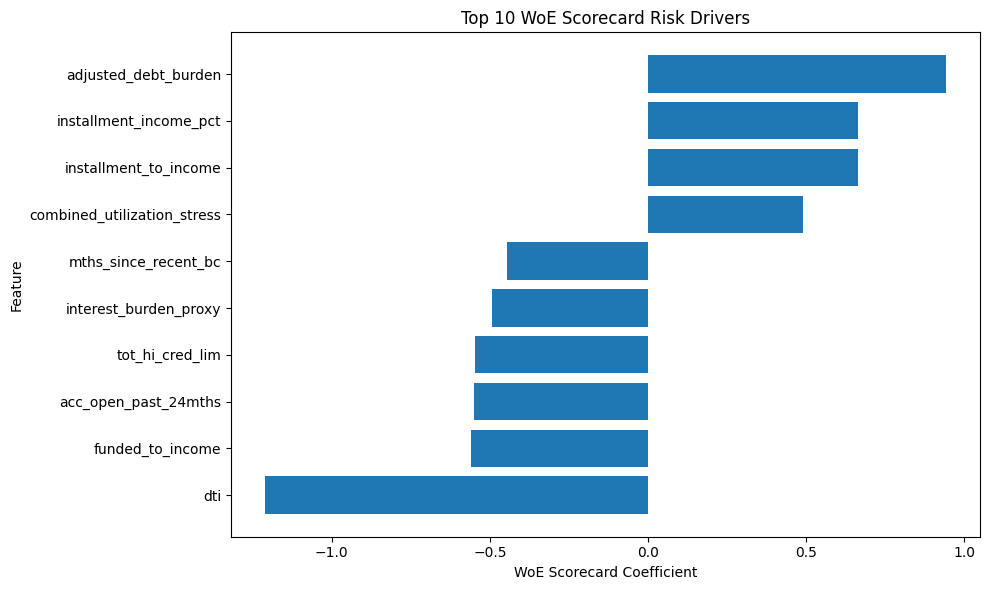

In [290]:

top_coeff=coefficients.head(10).sort_values("coefficient")

plt.figure(figsize=(10,6))
plt.barh(top_coeff["feature"],top_coeff["coefficient"])
plt.xlabel("WoE Scorecard Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 WoE Scorecard Risk Drivers")
plt.tight_layout()
plt.show()

In [291]:

feature_importance=coefficients.copy()
feature_importance["importance_pct"]=feature_importance["abs_coefficient"]/feature_importance["abs_coefficient"].sum()*100
feature_importance=feature_importance.sort_values("importance_pct",ascending=False)

print(feature_importance.head(20)[["feature","coefficient","importance_pct"]].to_string(index=False))

                    feature  coefficient  importance_pct
                        dti    -1.210457        8.015345
       adjusted_debt_burden     0.942035        6.237918
      installment_to_income     0.665323        4.405601
     installment_income_pct     0.665323        4.405601
           funded_to_income    -0.558686        3.699477
       acc_open_past_24mths    -0.551197        3.649892
            tot_hi_cred_lim    -0.547877        3.627905
      interest_burden_proxy    -0.492755        3.262901
combined_utilization_stress     0.490286        3.246551
       mths_since_recent_bc    -0.447253        2.961596
                tot_cur_bal     0.392439        2.598631
                   mort_acc    -0.386881        2.561829
             loan_to_income    -0.382859        2.535196
      mo_sin_rcnt_rev_tl_op     0.375137        2.484064
      loan_rate_interaction    -0.363725        2.408498
      grade_dti_interaction    -0.356895        2.363266
             monthly_income    

In [292]:
s=pd.DataFrame({
    "Metric":["Selected Features","Top Risk Driver","Top Risk Driver Coefficient","Top Importance (%)","Test ROC-AUC","Test Gini","Test KS","Test Brier Score"],
    "Value":[len(selected_iv_features),feature_importance.iloc[0]["feature"],round(feature_importance.iloc[0]["coefficient"],4),round(feature_importance.iloc[0]["importance_pct"],2),0.6916,0.3832,0.2796,0.1544]
})
print(s.to_string(index=False))

                     Metric   Value
          Selected Features      59
            Top Risk Driver     dti
Top Risk Driver Coefficient -1.2105
         Top Importance (%)    8.02
               Test ROC-AUC  0.6916
                  Test Gini  0.3832
                    Test KS  0.2796
           Test Brier Score  0.1544


In [293]:
def calculate_psi(expected,actual,bins=10):
    breakpoints=np.percentile(expected,np.linspace(0,100,bins+1))
    breakpoints=np.unique(breakpoints)
    breakpoints[0]=-np.inf
    breakpoints[-1]=np.inf
    expected_counts,_=np.histogram(expected,bins=breakpoints)
    actual_counts,_=np.histogram(actual,bins=breakpoints)
    expected_pct=expected_counts/len(expected)
    actual_pct=actual_counts/len(actual)
    expected_pct=np.clip(expected_pct,0.0001,None)
    actual_pct=np.clip(actual_pct,0.0001,None)
    psi=np.sum((actual_pct-expected_pct)*np.log(actual_pct/expected_pct))
    return psi

pd_psi=calculate_psi(woe_train_pd,woe_test_pd)
print("Training vs Test PSI:",round(pd_psi,4))

if pd_psi<0.10:
    print("Interpretation: Stable population")
elif pd_psi<0.25:
    print("Interpretation: Moderate population shift")
else:
    print("Interpretation: Significant population shift")

Training vs Test PSI: 0.0059
Interpretation: Stable population


In [294]:

top_features=feature_importance.head(10)["feature"].tolist()
feature_psi=[]

for col in top_features:
    train_values=X_woe_train[col].dropna().values
    test_values=X_test[col].dropna().values
    try:
        psi=calculate_psi(train_values,test_values)
        feature_psi.append({"feature":col,"psi":psi})
    except:
        pass

feature_psi_df=pd.DataFrame(feature_psi).sort_values("psi",ascending=False)

print(feature_psi_df.to_string(index=False))

                    feature      psi
combined_utilization_stress 0.210858
      installment_to_income 0.055324
     installment_income_pct 0.055324
           funded_to_income 0.045526
      interest_burden_proxy 0.044484
       acc_open_past_24mths 0.032667
            tot_hi_cred_lim 0.016379
       adjusted_debt_burden 0.011397
       mths_since_recent_bc 0.010528
                        dti 0.008577


In [295]:

train_default_rate=y_woe_train.mean()
val_default_rate=y_val.mean()
test_default_rate=y_test.mean()

print("Train default rate:",round(train_default_rate*100,2),"%")
print("Validation default rate:",round(val_default_rate*100,2),"%")
print("Test default rate:",round(test_default_rate*100,2),"%")

print("\nTrain-Test difference:",round(abs(train_default_rate-test_default_rate)*100,2),"percentage points")

Train default rate: 18.46 %
Validation default rate: 24.27 %
Test default rate: 21.03 %

Train-Test difference: 2.57 percentage points


In [296]:

feature_psi_df["status"]=np.where(feature_psi_df["psi"]<0.10,"Stable",np.where(feature_psi_df["psi"]<0.25,"Monitor","Investigate"))

print(feature_psi_df.to_string(index=False))

print("\nStability counts:")
print(feature_psi_df["status"].value_counts())

                    feature      psi  status
combined_utilization_stress 0.210858 Monitor
      installment_to_income 0.055324  Stable
     installment_income_pct 0.055324  Stable
           funded_to_income 0.045526  Stable
      interest_burden_proxy 0.044484  Stable
       acc_open_past_24mths 0.032667  Stable
            tot_hi_cred_lim 0.016379  Stable
       adjusted_debt_burden 0.011397  Stable
       mths_since_recent_bc 0.010528  Stable
                        dti 0.008577  Stable

Stability counts:
status
Stable     9
Monitor    1
Name: count, dtype: int64


In [298]:
ss=pd.DataFrame({
    "Metric":["PD PSI","Stable Features","Features to Monitor","Train Default Rate","Validation Default Rate","Test Default Rate"],
    "Value":[round(pd_psi,4),(feature_psi_df["status"]=="Stable").sum(),(feature_psi_df["status"]=="Monitor").sum(),round(train_default_rate*100,2),round(val_default_rate*100,2),round(test_default_rate*100,2)]
})
print(ss.to_string(index=False))

                 Metric   Value
                 PD PSI  0.0059
        Stable Features  9.0000
    Features to Monitor  1.0000
     Train Default Rate 18.4600
Validation Default Rate 24.2700
      Test Default Rate 21.0300


In [299]:

base_score=600
base_odds=50
pdo=20

test_score_odds=(1-woe_test_pd)/woe_test_pd
test_credit_score=base_score+(pdo/np.log(2))*np.log(test_score_odds/base_odds)
test_credit_score=np.round(test_credit_score,0)

print("CREDIT SCORE CONVERSION")
print("Base Score:",base_score)
print("Base Odds:",base_odds)
print("Points to Double Odds:",pdo)
print("Minimum Test Score:",int(test_credit_score.min()))
print("Maximum Test Score:",int(test_credit_score.max()))
print("Mean Test Score:",round(test_credit_score.mean(),2))

CREDIT SCORE CONVERSION
Base Score: 600
Base Odds: 50
Points to Double Odds: 20
Minimum Test Score: 455
Maximum Test Score: 610
Mean Test Score: 536.2


In [300]:

score_df=pd.DataFrame({"score":test_credit_score,"pd":woe_test_pd,"actual":y_test.values})

score_df["risk_band"]=pd.cut(score_df["score"],bins=[-np.inf,500,550,600,np.inf],labels=["Very High Risk","High Risk","Moderate Risk","Low Risk"])

score_summary=score_df.groupby("risk_band",observed=False).agg(
    loans=("actual","count"),
    avg_score=("score","mean"),
    avg_pd=("pd","mean"),
    actual_default_rate=("actual","mean")
).reset_index()

score_summary["avg_pd_pct"]=score_summary["avg_pd"]*100
score_summary["actual_default_rate_pct"]=score_summary["actual_default_rate"]*100

print(score_summary[["risk_band","loans","avg_score","avg_pd_pct","actual_default_rate_pct"]].to_string(index=False))

     risk_band  loans  avg_score  avg_pd_pct  actual_default_rate_pct
Very High Risk  16319 491.319811   46.390623                44.488020
     High Risk 128167 527.841511   20.615353                24.010081
 Moderate Risk  61513 565.420285    6.551021                 8.620942
      Low Risk    102 603.029412    1.775461                 3.921569


In [301]:

cutoffs=[500,525,550,575,600]

approval_results=[]

for cutoff in cutoffs:
    approved=test_credit_score>=cutoff
    approval_rate=approved.mean()*100
    default_rate=y_test.values[approved].mean()*100 if approved.sum()>0 else np.nan
    approval_results.append({"score_cutoff":cutoff,"approved_loans":approved.sum(),"approval_rate_pct":approval_rate,"approved_group_default_rate_pct":default_rate})

approval_df=pd.DataFrame(approval_results)

print("SCORECARD APPROVAL / REJECTION ANALYSIS")
print(approval_df.to_string(index=False))

SCORECARD APPROVAL / REJECTION ANALYSIS
 score_cutoff  approved_loans  approval_rate_pct  approved_group_default_rate_pct
          500          191057          92.700666                        19.131987
          525          137858          66.888564                        14.541049
          550           64182          31.141042                         8.804649
          575           13012           6.313409                         4.442053
          600             146           0.070839                         3.424658


In [302]:

final_project_summary=pd.DataFrame({
    "Metric":[
        "Dataset Size",
        "Engineered Features",
        "IV Selected Features",
        "Test ROC-AUC",
        "Test Gini",
        "Test KS",
        "Test Brier Score",
        "Optimal Threshold",
        "Test Recall at Optimal Threshold",
        "Test Precision at Optimal Threshold",
        "PD PSI",
        "Features Monitored"
    ],
    "Value":[
        len(df),
        50,
        len(selected_iv_features),
        0.6916,
        0.3832,
        0.2796,
        0.1544,
        round(optimal_threshold,4),
        round(recall,4),
        round(precision,4),
        round(pd_psi,4),
        (feature_psi_df["status"]=="Monitor").sum()
    ]
})

print(final_project_summary.to_string(index=False))

                             Metric        Value
                       Dataset Size 2260668.0000
                Engineered Features      50.0000
               IV Selected Features      59.0000
                       Test ROC-AUC       0.6916
                          Test Gini       0.3832
                            Test KS       0.2796
                   Test Brier Score       0.1544
                  Optimal Threshold       0.1740
   Test Recall at Optimal Threshold       0.6610
Test Precision at Optimal Threshold       0.3152
                             PD PSI       0.0059
                 Features Monitored       1.0000
